# 1. Análisis del Impacto de Noticias y Opiniones en la Volatilidad de Memecoins mediante NLP

A continuación en este notebook se realizará un EDA de los diferentes ficheros a emplear durante el proyecto, también se analizará los sentimientos de uno de los datasets recogidos y por último se analizarán la relación entre las diferentes opiniones con la volatilidad de los memecoins.

In [ ]:
#imports e instalación de librerias

!pip install pymongo
!pip install pandas==2.2.2 matplotlib==3.10.0 tensorflow==2.18.0 scikit-learn==1.3.2
import os
import re
import time
import openai
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.offsets import BDay
from pymongo import MongoClient
from datetime import datetime
from nltk import download as nltk_download
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, r2_score
from sklearn.metrics import mean_squared_error, r2_score



  Using cached numpy-1.23.0.tar.gz (10.7 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Función genérica para obtener la colección más reciente por prefijo
def get_latest_collection_by_prefix(prefix: str):
    collections = db.list_collection_names()
    filtered = sorted([name for name in collections if name.startswith(prefix)], reverse=True)

    # Si no existe la colección, crearla con la fecha actual
    if not filtered:
        print(f"No se encontró ninguna colección que comience con '{prefix}'. Creando una nueva.")
        today_str = datetime.today().strftime("%d_%m_%y")  # Obtener la fecha actual en formato DD_MM_YY
        collection_name = f"{prefix}{today_str}"
        collection = db.create_collection(collection_name)  # Crear la nueva colección
        return collection, collection_name

    return db[filtered[0]], filtered[0]

# Leer las credenciales desde el archivo JSON
with open('config.json', 'r') as f:
    config = json.load(f)

uri = config["mongo_uri"]

# Conectar a MongoDB
client = MongoClient(uri)
db = client["crypto_analysis"]

# Acceder a las colecciones más recientes o crear nuevas si no existen
collection_volatility, vol_name = get_latest_collection_by_prefix("memecoins_volatility_data_")
collection_prices, price_name = get_latest_collection_by_prefix("memecoins_prices_data_")
collection_reddit, reddit_news = get_latest_collection_by_prefix("memecoins_reddit_raw_")
collection_sentiment_vader, reddit_sentiment_vader = get_latest_collection_by_prefix("memecoins_reddit_sentiment_vader_")
collection_sentiment_bert, reddit_sentiment_bert = get_latest_collection_by_prefix("memecoins_reddit_sentiment_bert_")
collection_sentiment_gpt, reddit_sentiment_gpt = get_latest_collection_by_prefix("memecoins_reddit_sentiment_gpt_")

# Imprimir el nombre de las colecciones
print(f"Volatility collection: {vol_name}")
print(f"Prices collection: {price_name}")
print(f"Reddit news collection: {reddit_news}")
print(f"Sentiment Vader collection: {reddit_sentiment_vader}")
print(f"Sentiment BERT collection: {reddit_sentiment_bert}")
print(f"Sentiment GPT collection: {reddit_sentiment_gpt}")

Volatility collection: memecoins_volatility_data_05_06_2025
Prices collection: memecoins_prices_data_05_06_25
Reddit news collection: memecoins_reddit_raw_04_06_25
Sentiment Vader collection: memecoins_reddit_sentiment_vader_11_06_25
Sentiment BERT collection: memecoins_reddit_sentiment_bert_11_06_25
Sentiment GPT collection: memecoins_reddit_sentiment_gpt_11_06_25


# 2. EDA de Datos de Criptomonedas
 En este punto realizaremos un Análisis Exploratorio de Datos (EDA) utilizando dos conjuntos de datos relacionados con la volatilidad de criptomonedas.

 El primer conjunto contiene información sobre PEPE, DOGE y SHIBA durante 365 días, y el segundo conjunto sobre el precio diario en 365 días será analizado de manera similar.

 Utilizaremos bibliotecas como ggplot2, dplyr y otros para explorar y visualizar las métricas relacionadas con el rango de precios, cambio
 porcentual y volatilidad relativa.


## 2.1 EDA sobre memecoins_volatility_data

In [ ]:

# Leer los datos y convertirlos en DataFrames
data_volatility = list(collection_volatility.find())

df_vol = pd.DataFrame(data_volatility)

# Verificar los nombres usados
print(f" Estructura de la Colección de volatilidad usada: {vol_name}")

# Verificar las primeras filas
print(df_vol.head())

 Estructura de la Colección de volatilidad usada: memecoins_volatility_data_05_06_2025
                        _id       date      open      high       low  \
0  6841474867ab49933a560829 2024-06-22  0.000011  0.000012  0.000010   
1  6841474867ab49933a56082a 2024-06-26  0.000011  0.000013  0.000010   
2  6841474867ab49933a56082c 2024-07-04  0.000011  0.000012  0.000010   
3  6841474867ab49933a560837 2024-08-17  0.000008  0.000008  0.000007   
4  6841474867ab49933a560858 2024-12-27  0.000018  0.000019  0.000017   

      close     range  pct_change  rel_volatility  coin  
0  0.000011  0.000002    2.148612        0.186067  pepe  
1  0.000013  0.000003   11.975524        0.232918  pepe  
2  0.000010  0.000002   -9.380531        0.186907  pepe  
3  0.000007  0.000002  -12.879708        0.195567  pepe  
4  0.000017  0.000002   -2.579921        0.125376  pepe  


In [ ]:
# Asegurarse de que la columna 'date' esté en formato datetime
df_vol['date'] = pd.to_datetime(df_vol['date'])

# Verificar los tipos de datos (opcional)
print(df_vol.dtypes)

# Obtener la lista de monedas únicas
coins = df_vol['coin'].unique()

# Generar resumen estadístico por cada coin
for coin in coins:
    print(f"\nResumen estadístico para {coin}:")
    print(df_vol[df_vol['coin'] == coin].describe())

# Convertir columna 'date' a datetime
df_vol['date'] = pd.to_datetime(df_vol['date'])

# Lista de columnas numéricas
numeric_cols = ['open', 'high', 'low', 'close', 'range', 'pct_change', 'rel_volatility']

# Reemplazar ',' por '.' SOLO si es string, luego convertir a float
for col in numeric_cols:
    if df_vol[col].dtype == 'object':
        df_vol[col] = df_vol[col].str.replace(',', '.')
        df_vol[col] = pd.to_numeric(df_vol[col], errors='coerce')

# Confirmar tipos de datos
print(df_vol.dtypes)

# Ver resumen correcto para PEPE
print("\nResumen estadístico para PEPE:")
print(df_vol[df_vol['coin'] == 'pepe'][numeric_cols].describe())

_id                       object
date              datetime64[ns]
open                     float64
high                     float64
low                      float64
close                    float64
range                    float64
pct_change               float64
rel_volatility           float64
coin                      object
dtype: object

Resumen estadístico para pepe:
                      date       open       high        low      close  \
count                   92  92.000000  92.000000  92.000000  92.000000   
mean   2024-12-05 00:00:00   0.000012   0.000013   0.000010   0.000012   
min    2024-06-06 00:00:00   0.000007   0.000007   0.000005   0.000007   
25%    2024-09-05 00:00:00   0.000008   0.000009   0.000008   0.000008   
50%    2024-12-05 00:00:00   0.000010   0.000011   0.000009   0.000010   
75%    2025-03-06 00:00:00   0.000014   0.000015   0.000012   0.000014   
max    2025-06-05 00:00:00   0.000024   0.000028   0.000022   0.000024   
std                    NaN   0.0

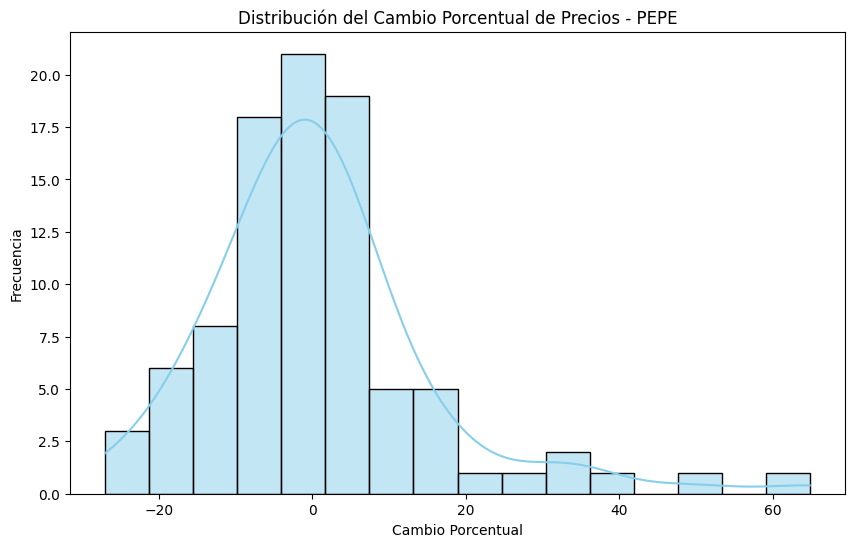

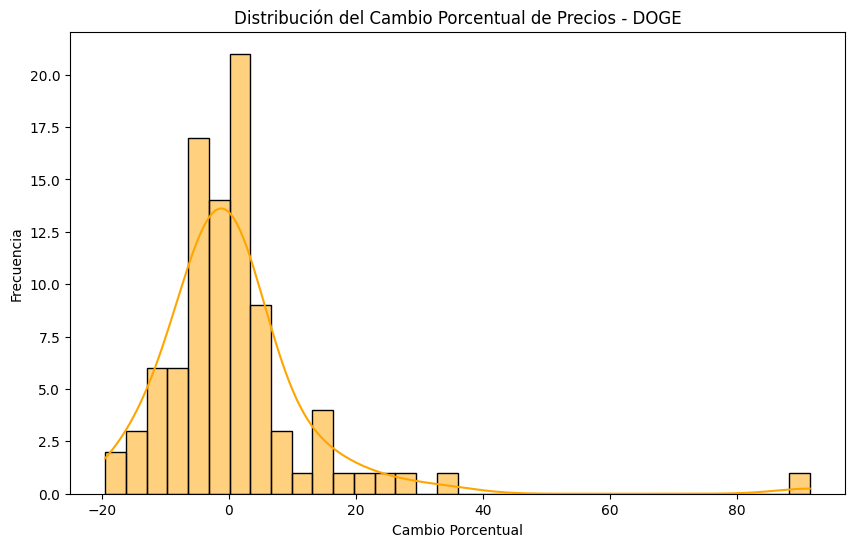

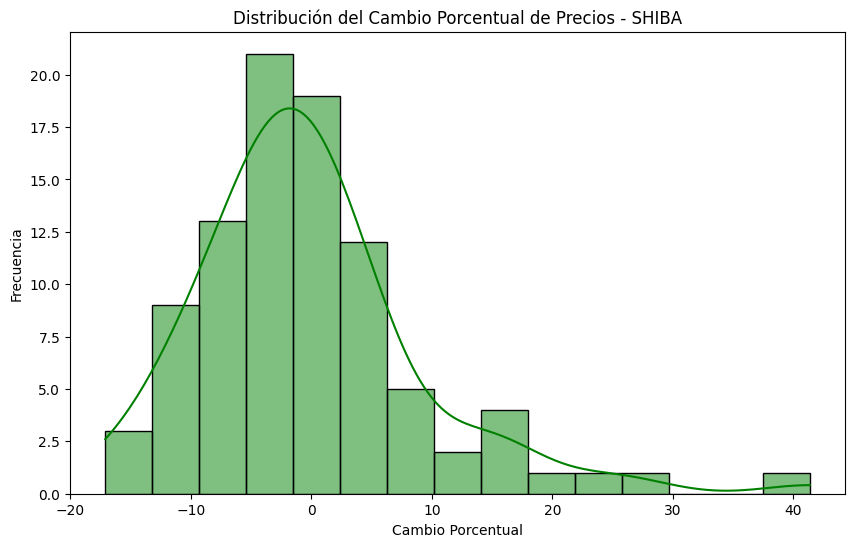

In [ ]:
# Filtrar los datos para cada criptomoneda y crear los histogramas para cada una

# Histograma para PEPE
plt.figure(figsize=(10, 6))
sns.histplot(df_vol[df_vol['coin'] == 'pepe']['pct_change'], kde=True, color='skyblue')
plt.title('Distribución del Cambio Porcentual de Precios - PEPE')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para DOGE
plt.figure(figsize=(10, 6))
sns.histplot(df_vol[df_vol['coin'] == 'doge']['pct_change'], kde=True, color='orange')
plt.title('Distribución del Cambio Porcentual de Precios - DOGE')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para SHIBA
plt.figure(figsize=(10, 6))
sns.histplot(df_vol[df_vol['coin'] == 'shiba']['pct_change'], kde=True, color='green')
plt.title('Distribución del Cambio Porcentual de Precios - SHIBA')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

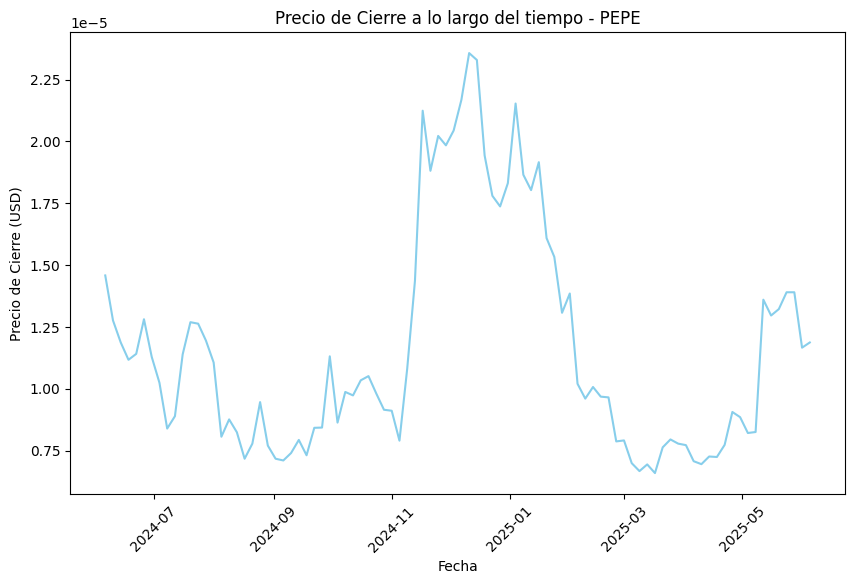

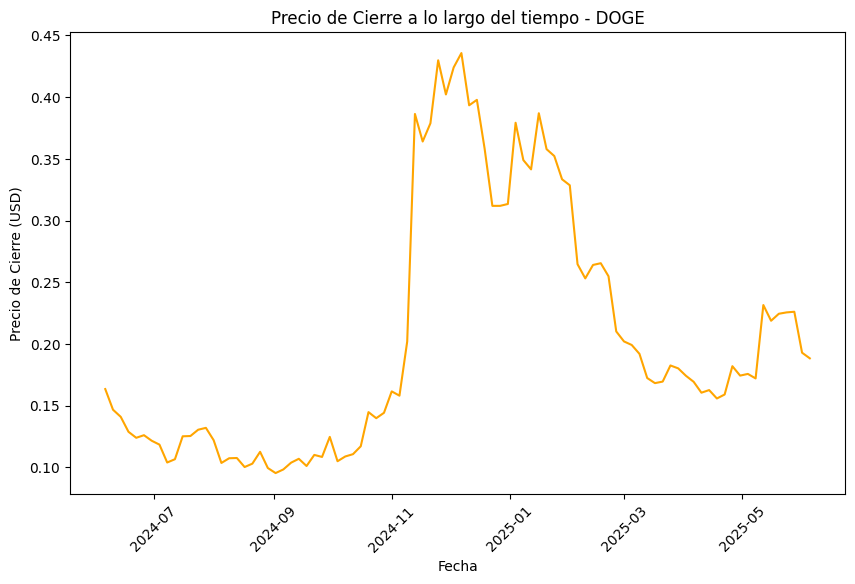

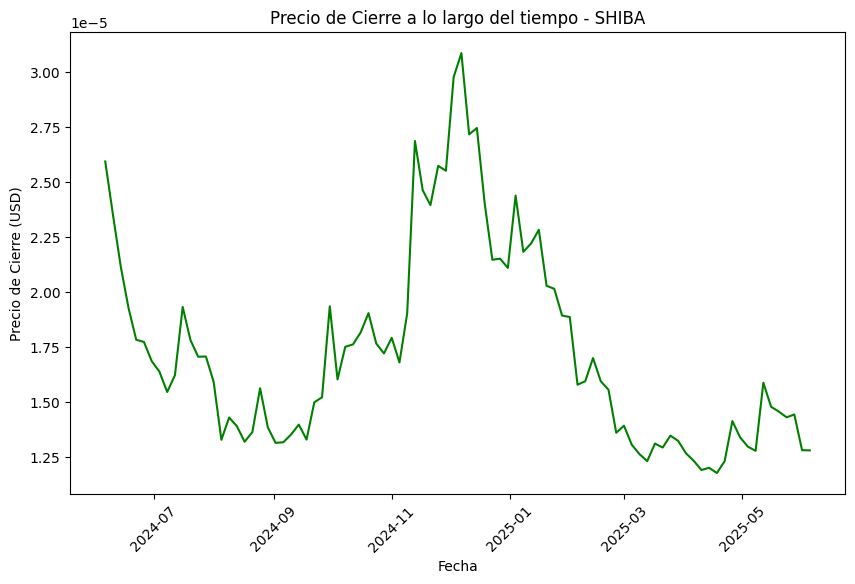

In [ ]:
# Gráfico de serie temporal para PEPE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=df_vol[df_vol['coin'] == 'pepe'], color='skyblue')
plt.title('Precio de Cierre a lo largo del tiempo - PEPE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para DOGE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=df_vol[df_vol['coin'] == 'doge'], color='orange')
plt.title('Precio de Cierre a lo largo del tiempo - DOGE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para SHIBA
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=df_vol[df_vol['coin'] == 'shiba'], color='green')
plt.title('Precio de Cierre a lo largo del tiempo - SHIBA')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()


## 2.2 EDA sobre memecoins_prices_data

In [ ]:
# Leer los datos y convertirlos en DataFrames
data_prices = list(collection_prices.find())

df_prices = pd.DataFrame(data_prices)

# Verificar los nombres usados
print(f" Estructura de la Colección de precios usada: {price_name}")

# Verificar las primeras filas
print(df_prices.head())

 Estructura de la Colección de precios usada: memecoins_prices_data_05_06_25
                        _id       date  coin     price        volume  \
0  684145304a860b1d4f3f0222 2024-06-21  pepe  0.000011  8.090444e+08   
1  684145304a860b1d4f3f023d 2024-07-18  pepe  0.000012  1.487600e+09   
2  684145304a860b1d4f3f0255 2024-08-11  pepe  0.000008  5.691814e+08   
3  684145304a860b1d4f3f0257 2024-08-13  pepe  0.000008  1.169279e+09   
4  684145304a860b1d4f3f0269 2024-08-31  pepe  0.000008  1.039300e+09   

     market_cap  
0  4.618936e+09  
1  4.922633e+09  
2  3.546677e+09  
3  3.472503e+09  
4  3.273542e+09  


In [ ]:
# Conversión de tipos de datos
df_prices['date'] = pd.to_datetime(df_prices['date'])
df_prices['price'] = df_prices['price'].astype(float)

# Redondear los precios
df_prices['price_rounded_no_exp'] = df_prices['price'].apply(lambda x: round(x, 8))

# Verificar los tipos de datos después de la conversión
print(df_prices.dtypes)

# Obtener lista de monedas
coins = df_prices['coin'].unique()

# Resumen estadístico por moneda
for coin in coins:
    print(f"\nResumen estadístico de precios para {coin}:")
    print(df_prices[df_prices['coin'] == coin].describe())


_id                             object
date                    datetime64[ns]
coin                            object
price                          float64
volume                         float64
market_cap                     float64
price_rounded_no_exp           float64
dtype: object

Resumen estadístico de precios para pepe:
                                date       price        volume    market_cap  \
count                            372  372.000000  3.720000e+02  3.720000e+02   
mean   2024-12-08 10:11:36.774193664    0.000012  1.712367e+09  4.910378e+09   
min              2024-06-06 00:00:00    0.000006  3.020866e+08  2.429367e+09   
25%              2024-09-06 18:00:00    0.000008  7.627871e+08  3.399605e+09   
50%              2024-12-08 12:00:00    0.000010  1.081860e+09  4.243513e+09   
75%              2025-03-11 06:00:00    0.000013  1.770576e+09  5.653294e+09   
max              2025-06-05 00:00:00    0.000026  1.918689e+10  1.110002e+10   
std                           

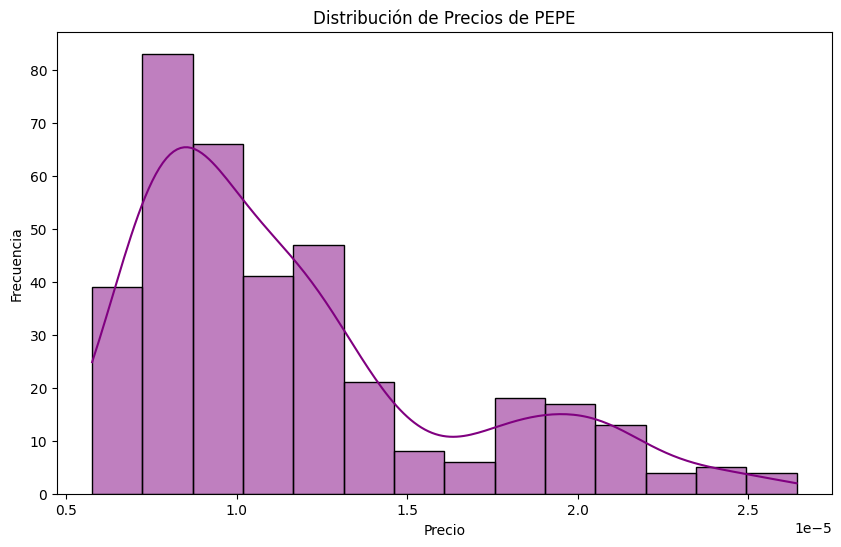

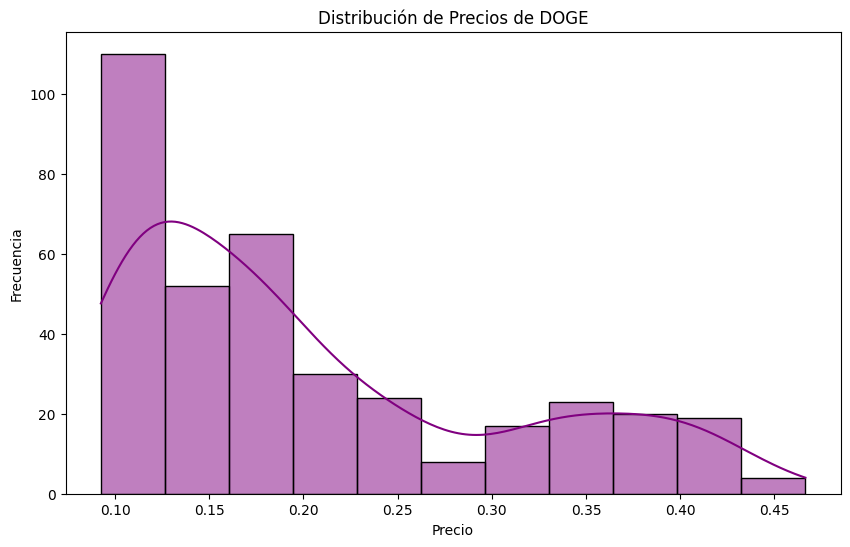

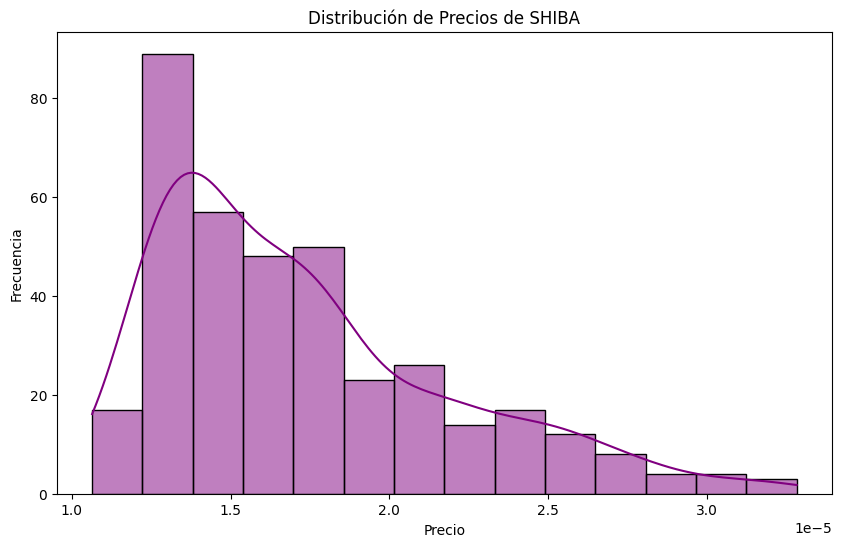

In [ ]:
# Histograma de precios para cada criptomoneda
for coin in df_prices['coin'].unique():
    plt.figure(figsize=(10, 6))
    sns.histplot(df_prices[df_prices['coin'] == coin]['price_rounded_no_exp'], kde=True, color='purple')
    plt.title(f'Distribución de Precios de {coin.upper()}')
    plt.xlabel('Precio')
    plt.ylabel('Frecuencia')
    plt.show()


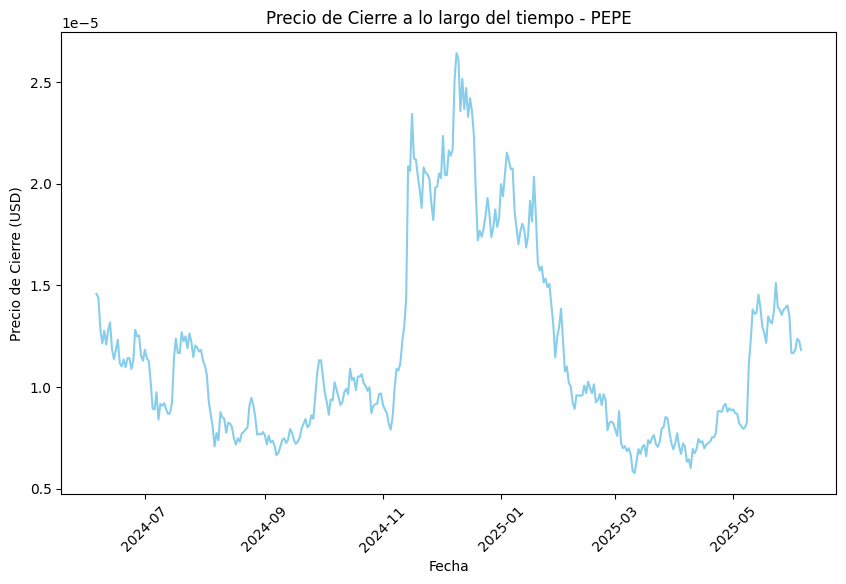

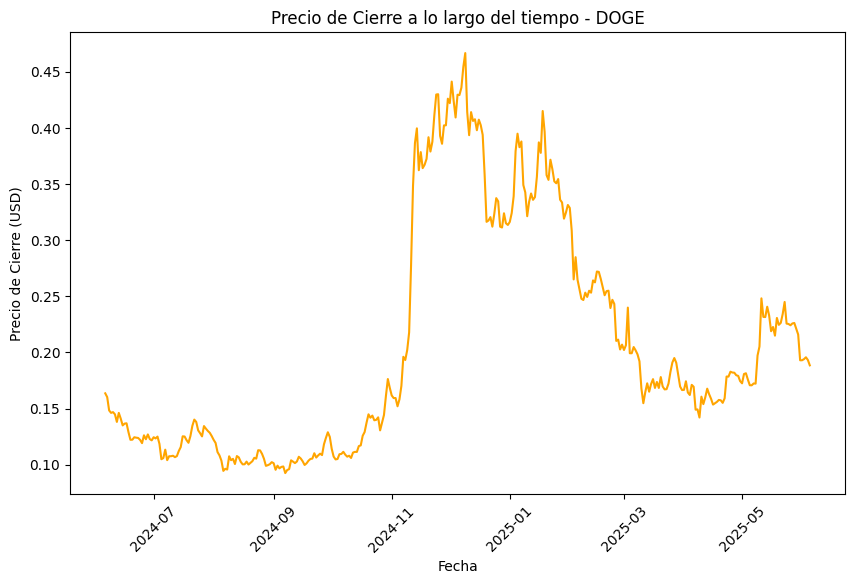

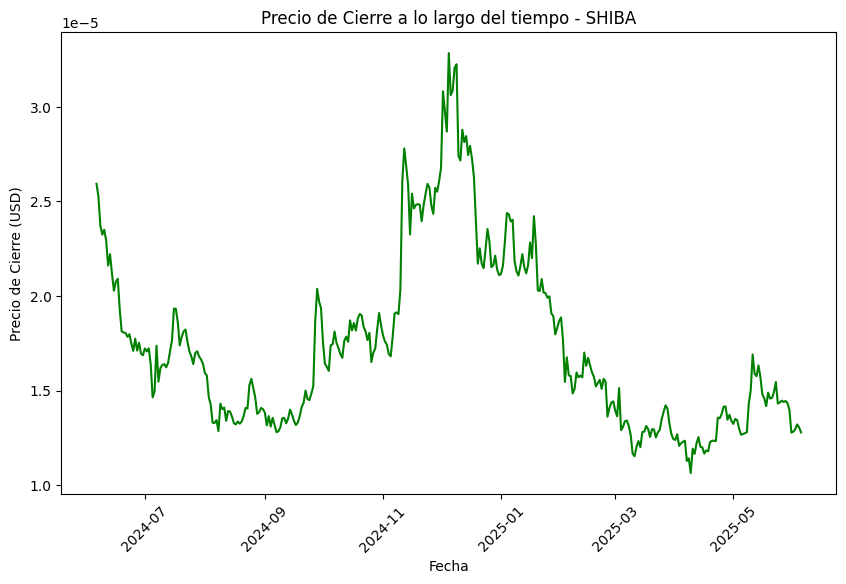

In [ ]:
# Gráfico de serie temporal para PEPE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=df_prices[df_prices['coin'] == 'pepe'], color='skyblue')
plt.title('Precio de Cierre a lo largo del tiempo - PEPE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para DOGE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=df_prices[df_prices['coin'] == 'doge'], color='orange')
plt.title('Precio de Cierre a lo largo del tiempo - DOGE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para SHIBA
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=df_prices[df_prices['coin'] == 'shiba'], color='green')
plt.title('Precio de Cierre a lo largo del tiempo - SHIBA')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

## 2.3 EDA sobre news_data


In [ ]:
# Leer los datos y convertirlos en DataFrames
data_news = list(collection_reddit.find())

df_news = pd.DataFrame(data_news)

# Verificar los nombres usados
print(f" Estructura de la Colección de precios usada: {price_name}")
# Verificar los tipos de datos después de la conversión
print(df_news.dtypes)

# Obtener lista de sources
sources = df_news['subreddit'].unique()
print(f" Lista de subrredits empleados: {sources}")

 Estructura de la Colección de precios usada: memecoins_prices_data_05_06_25
_id                  object
date         datetime64[ns]
title                object
selftext             object
url                  object
subreddit            object
coin                 object
filter               object
dtype: object
 Lista de subrredits empleados: ['CryptoCurrency' 'altcoin' 'dogecoin' 'worldnews' 'Economics' 'Bitcoin'
 'ethereum' 'SHIBArmy' 'shiba' 'pepecoin' 'PEPEthefrog' 'cryptomoonshots']


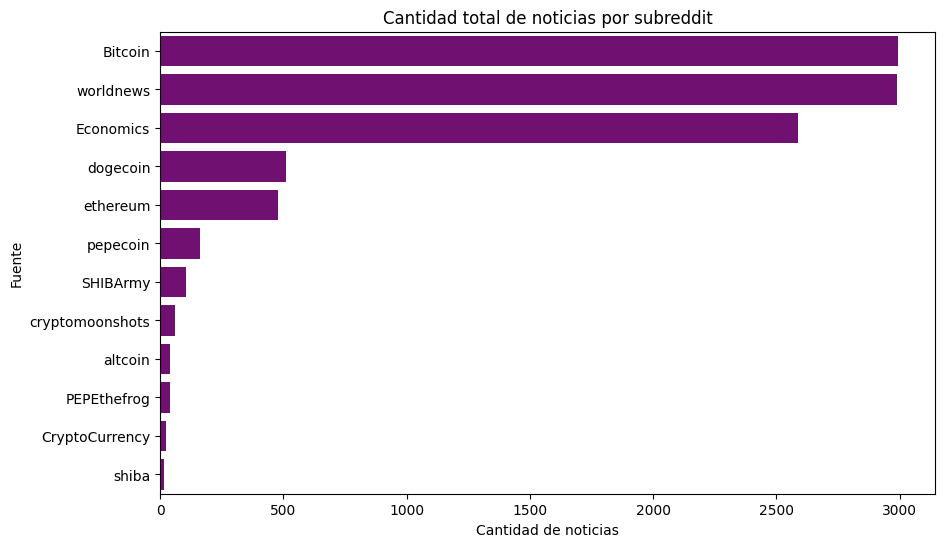

In [ ]:
# Gráfico de barras de cantidad total de noticias por fuente (subrredit)
plt.figure(figsize=(10,6))
sns.countplot(data=df_news, y='subreddit', color='purple', order=df_news['subreddit'].value_counts().index)
plt.title('Cantidad total de noticias por subreddit')
plt.xlabel('Cantidad de noticias')
plt.ylabel('Fuente')
plt.show()

# 3. Análisis de sentimientos
En este punto realizamos el análisis de los textos recogidos de Reddit y sus diferentes subreddits sobre noticias financieras utilizando tres algoritmos distintos de análisis de sentimiento, con el objetivo de comparar su precisión y consistencia en contextos relacionados con mercados volátiles y memecoins:

BERT (Bidirectional Encoder Representations from Transformers): Un modelo de deep learning preentrenado desarrollado por Google, que se adapta mediante fine-tuning para tareas de análisis de sentimientos. En este trabajo se utiliza una variante optimizada para textos en inglés (e.g., bert-base-uncased ajustado con corpus de clasificación de sentimientos como SST-2 o FinBERT), la cual permite clasificar cada entrada como positiva, negativa o neutral. Estas etiquetas se traducen a una escala numérica entre 0 y 1 para facilitar la comparación con los otros métodos.

VADER (Valence Aware Dictionary and sEntiment Reasoner): Un modelo basado en reglas y diccionario, optimizado para textos sociales en inglés. Su índice compound se transforma a una escala de 0 a 1 para su comparación.

ChatGPT a través de la API de OpenAI: Un enfoque más contextual y flexible basado en modelos de lenguaje avanzados, que devuelve una puntuación de sentimiento entre 0 y 1 interpretando directamente cada titular.

#3.1 **BERT**

In [ ]:
# Inicializar el pipeline de análisis de sentimientos con un modelo BERT entrenado en datos financieros
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
bert_sentiment = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda:0


In [ ]:
# Preparar el texto combinando título y cuerpo
df_news["text"] = df_news["title"].fillna('') + " " + df_news["selftext"].fillna('')

# Asegurarse de que el texto no esté vacío
df_news["text"] = df_news["text"].apply(lambda x: x.strip())

# Aplicar el análisis de sentimientos con BERT y medir el tiempo de ejecución
start_time = time.time()

def get_bert_score(text):
    try:
        if len(text) < 5:  # Verificar que el texto no sea demasiado corto
            return None

        # Realizar el análisis de sentimientos con BERT
        result = bert_sentiment(text[:512])[0]  # Truncar a 512 tokens si es necesario
        label = result["label"]  # Obtener la etiqueta

        # Mapear las estrellas de 1-5 a un rango de 0-1
        if label == "1 star":
            return 0.0
        elif label == "2 stars":
            return 0.25
        elif label == "3 stars":
            return 0.5
        elif label == "4 stars":
            return 0.75
        elif label == "5 stars":
            return 1.0
        else:
            return None  # Si no es una de las estrellas, devolver None
    except Exception as e:
        print(f"Error al procesar el texto: {text}")
        print(f"Excepción: {e}")
        return None

# Aplicar la función de análisis de sentimientos a cada texto
df_news["score"] = df_news["text"].apply(get_bert_score)

# Medir el tiempo de ejecución
end_time = time.time()
print(f"Tiempo de ejecución de BERT: {end_time - start_time:.2f} segundos")

# Guardar colección con sentimiento en MongoDB
today_str = datetime.today().strftime("%d_%m_%y")
collection_sentiment_bert = db[f"memecoins_reddit_sentiment_bert_{today_str}"]

# Eliminar la colección existente si ya existe
if collection_sentiment_bert.name in db.list_collection_names():
    db.drop_collection(collection_sentiment_bert.name)

# Insertar los resultados en la base de datos (sin la columna de texto)
collection_sentiment_bert.insert_many(df_news.drop(columns=["text"]).to_dict("records"))

print(f"Sentimientos BERT guardados en: memecoins_reddit_sentiment_bert_{today_str}")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Tiempo de ejecución de BERT: 132.38 segundos
Sentimientos BERT guardados en: memecoins_reddit_sentiment_bert_11_06_25


Resumen por moneda (BERT):
   coin  count      mean       std  min  max
0  DOGE   3550  0.361901  0.431112  0.0  1.0
1  PEPE   3307  0.360145  0.430716  0.0  1.0
2  SHIB   3153  0.350301  0.424070  0.0  1.0


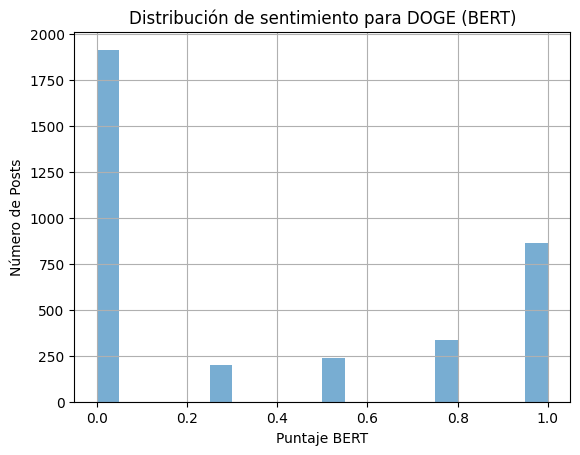

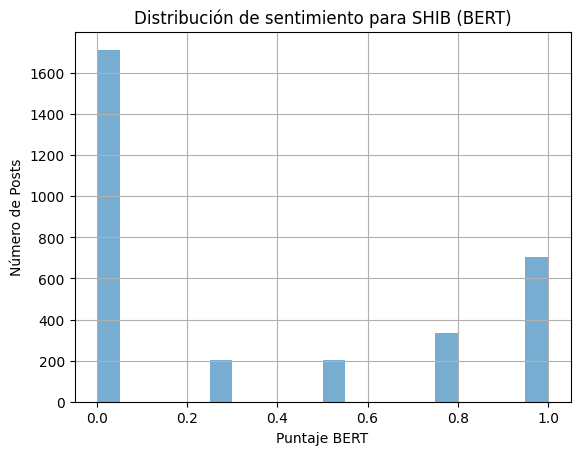

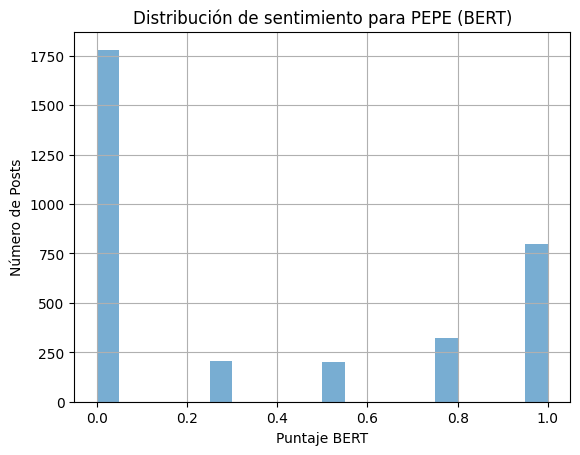

Evolución temporal del sentimiento (promedio diario por moneda) - BERT:


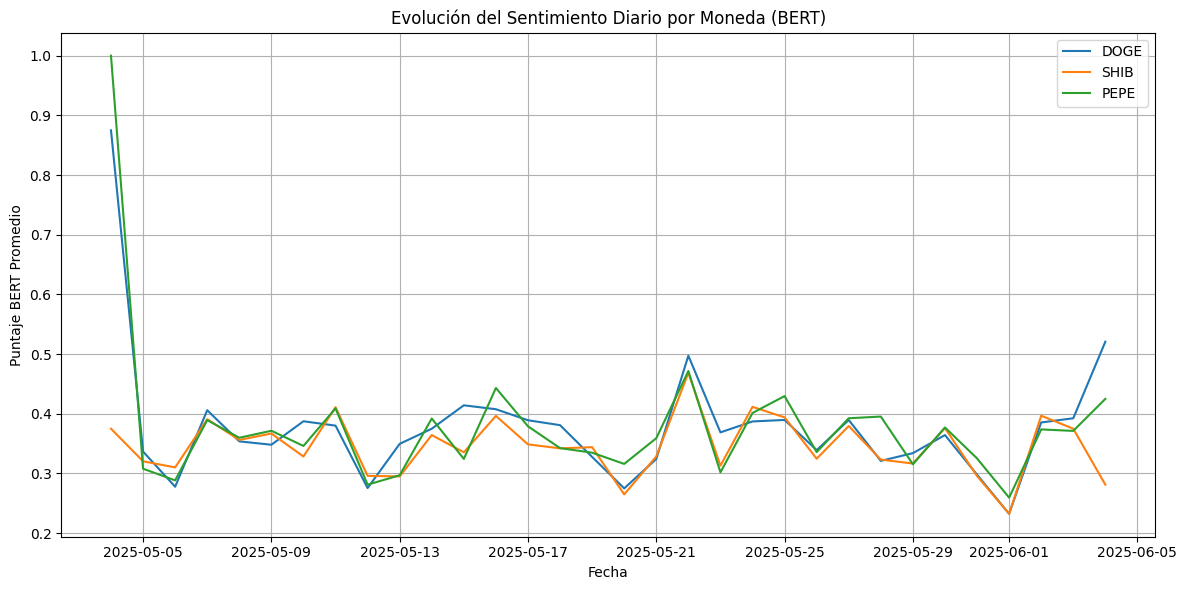

In [ ]:
data = list(collection_sentiment_bert.find())
df_bert = pd.DataFrame(data)

# Limpiar los datos: Asegurarnos de que los scores estén entre 0 y 1 y que las monedas no tengan valores nulos
df_bert["score"] = df_bert["score"].apply(lambda x: max(0, min(1, x)))  # Asegurar que score esté entre 0 y 1
df_bert["coin"] = df_bert["coin"].fillna("Unknown")  # Rellenar posibles valores nulos en coin

# **Análisis Básico**
summary_bert = df_bert.groupby("coin")["score"].agg(["count", "mean", "std", "min", "max"]).reset_index()
print("Resumen por moneda (BERT):")
print(summary_bert)

# **Gráficos**
for coin in df_bert["coin"].unique():
    df_bert[df_bert["coin"] == coin]["score"].hist(bins=20, alpha=0.6)
    plt.title(f"Distribución de sentimiento para {coin} (BERT)")
    plt.xlabel("Puntaje BERT")
    plt.ylabel("Número de Posts")
    plt.grid(True)
    plt.show()

# **Gráfico de evolución temporal del sentimiento promedio diario**
print("Evolución temporal del sentimiento (promedio diario por moneda) - BERT:")
plt.figure(figsize=(12, 6))

for coin in df_bert["coin"].unique():
    daily_avg_bert = (
        df_bert[df_bert["coin"] == coin]
        .groupby(df_bert["date"].dt.date)["score"]
        .mean()
    )
    plt.plot(daily_avg_bert.index, daily_avg_bert.values, label=coin.upper())

plt.title("Evolución del Sentimiento Diario por Moneda (BERT)")
plt.xlabel("Fecha")
plt.ylabel("Puntaje BERT Promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#3.2 **VADER**

In [ ]:
# Inicializar VADER
try:
    sia = SentimentIntensityAnalyzer()
except:
    nltk_download("vader_lexicon")
    sia = SentimentIntensityAnalyzer()

In [ ]:
# Aplicar VADER
start_time_VADER = time.time()
df_news["text"] = df_news["title"].fillna('') + " " + df_news["selftext"].fillna('')
df_news["score"] = df_news["text"].apply(lambda x: sia.polarity_scores(x)["compound"])

end_time_VADER = time.time()
print(f"Tiempo de ejecución de VADER: {end_time_VADER - start_time_VADER:.2f} segundos")
# Guardar colección con sentimiento
today_str = datetime.today().strftime("%d_%m_%y")
collection_sentiment = db[f"memecoins_reddit_sentiment_vader_{today_str}"]
# Eliminar la colección existente si ya existe
if collection_sentiment.name in db.list_collection_names():
    db.drop_collection(collection_sentiment.name)
collection_sentiment.insert_many(df_news.drop(columns=["text"]).to_dict("records"))
print(f"Sentimientos guardados en: memecoins_reddit_sentiment_vader_{today_str}")

Tiempo de ejecución de VADER: 8.31 segundos
Sentimientos guardados en: memecoins_reddit_sentiment_vader_11_06_25


### 3.2.1 EDA news_data_sentimental_analysis_mean_VADER


Resumen por moneda:
   coin  count      mean       std     min     max
0  DOGE   3550  0.047824  0.439425 -0.9996  0.9995
1  PEPE   3307  0.061733  0.465425 -0.9996  0.9995
2  SHIB   3153  0.048370  0.464324 -0.9996  0.9992


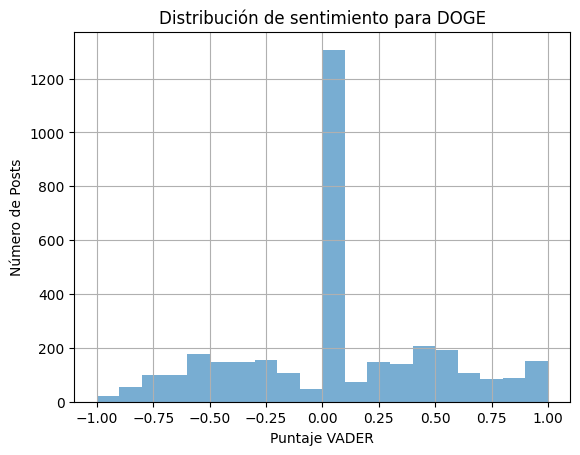

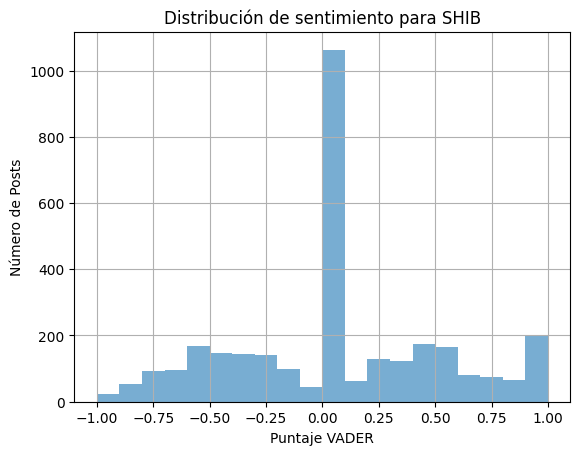

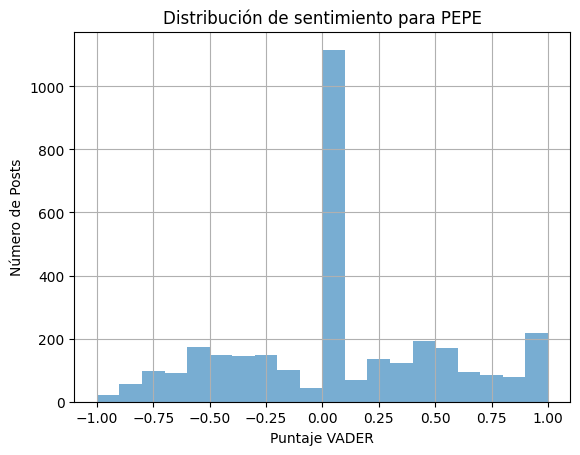

Evolución temporal del sentimiento (promedio diario por moneda):


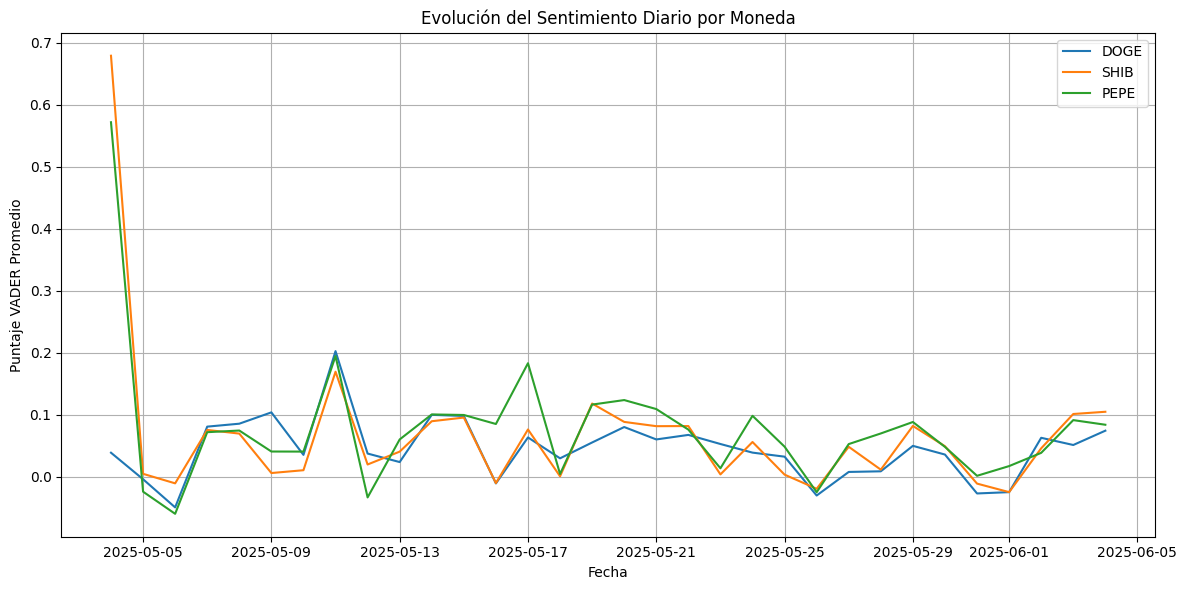

In [ ]:
# Análisis básico
summary = df_news.groupby("coin")["score"].agg(["count", "mean", "std", "min", "max"]).reset_index()
print("Resumen por moneda:")
print(summary)

# Gráficos
for coin in df_news["coin"].unique():
    df_news[df_news["coin"] == coin]["score"].hist(bins=20, alpha=0.6)
    plt.title(f"Distribución de sentimiento para {coin}")
    plt.xlabel("Puntaje VADER")
    plt.ylabel("Número de Posts")
    plt.grid(True)
    plt.show()

# Gráfico de evolución temporal del sentimiento promedio diario
print("Evolución temporal del sentimiento (promedio diario por moneda):")
plt.figure(figsize=(12, 6))

for coin in df_news["coin"].unique():
    daily_avg = (
        df_news[df_news["coin"] == coin]
        .groupby(df_news["date"].dt.date)["score"]
        .mean()
    )
    plt.plot(daily_avg.index, daily_avg.values, label=coin.upper())

plt.title("Evolución del Sentimiento Diario por Moneda")
plt.xlabel("Fecha")
plt.ylabel("Puntaje VADER Promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#3.3 **GPT**




In [ ]:
# Función para obtener el sentimiento usando la nueva API de OpenAI (Modelo "gpt-4.1-nano")
def get_sentiment_from_gpt(texts):
    """
    Esta función maneja el límite de tasa y realiza reintentos si es necesario.
    """
    sentiments = []
    for text in texts:
        try:
            response = openai.ChatCompletion.create(
                model="gpt-4.1-nano",  # Ajustamos el modelo aquí
                messages=[
                    {"role": "system", "content": "You are a sentiment analyzer. Return a number between 0 and 1, where 0 is negative, 0.5 is neutral, and 1 is positive. Only return the number, up to 3 decimal places."},
                    {"role": "user", "content": text}
                ]
            )
            sentiment = response['choices'][0]['message']['content'].strip()

            # Usar expresión regular para extraer solo el número
            match = re.match(r"^\d(\.\d{1,3})?$", sentiment)  # Esto acepta números como 0, 0.5, 1, etc.
            if match:
                sentiments.append(float(match.group(0)))  # Convertir el valor extraído a float
            else:
                sentiments.append(0)  # En caso de que la respuesta no sea un número válido
        except openai.error.RateLimitError:
            print("Límite de tasa alcanzado. Esperando 20 segundos...")
            time.sleep(20)  # Esperar antes de reintentar
            sentiments.append(0)  # Devolver 0 como valor predeterminado
        except Exception as e:
            print(f"Error al obtener el sentimiento de GPT: {e}")
            sentiments.append(0)  # Retornar neutral si hay un error
    return sentiments

In [ ]:
data_news = list(collection_reddit.find())
df_news = pd.DataFrame(data_news)

# Limpiar y preparar el texto para el análisis
df_news["text"] = df_news["title"].fillna('') + " " + df_news["selftext"].fillna('')

# Aplicar el análisis de sentimiento usando GPT en lotes
start_time_gpt = time.time()

# Dividir los textos en lotes de tamaño 10 (ajustable según el límite de la API)
batch_size = 10
sentiment_scores = []
for i in range(0, len(df_news), batch_size):
    batch = df_news["text"].iloc[i:i + batch_size].tolist()
    scores = get_sentiment_from_gpt(batch)
    sentiment_scores.extend(scores)

# Asignar los sentimientos calculados a la columna 'score'
df_news["score"] = sentiment_scores

end_time_gpt = time.time()

print(f"Tiempo de ejecución con GPT: {end_time_gpt - start_time_gpt:.2f} segundos")

# Guardar los resultados en la colección de sentimientos
today_str = datetime.today().strftime("%d_%m_%y")
collection_sentiment = db[f"memecoins_reddit_sentiment_gpt_{today_str}"]

# Eliminar la colección existente si ya existe
if collection_sentiment.name in db.list_collection_names():
    db.drop_collection(collection_sentiment.name)

# Insertar los registros con el sentimiento calculado
collection_sentiment.insert_many(df_news.drop(columns=["text"]).to_dict("records"))

print(f"Sentimientos guardados en: memecoins_reddit_sentiment_gpt_{today_str}")

Límite de tasa alcanzado. Esperando 20 segundos...

Límite de tasa alcanzado. Esperando 20 segundos...

Tiempo de ejecución con GPT: 3808.20 segundos

Sentimientos guardados en: memecoins_reddit_sentiment_gpt_11_06_25

### 3.3.1 EDA sobre datos de GPT

Resumen por moneda:
   coin  count      mean       std  min    max
0  DOGE   3550  0.508986  0.231678  0.0  1.000
1  PEPE   3307  0.498888  0.232158  0.0  0.998
2  SHIB   3153  0.494602  0.231240  0.0  0.982


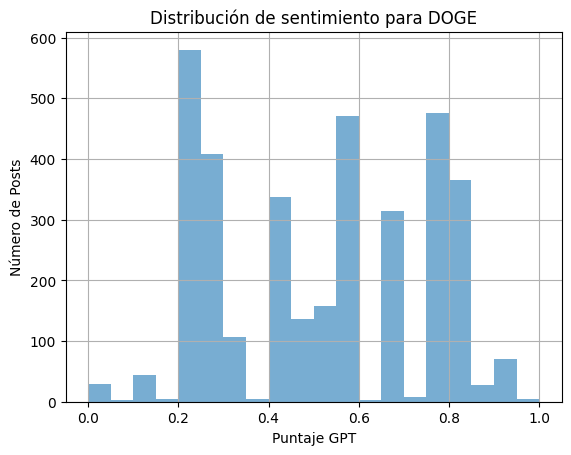

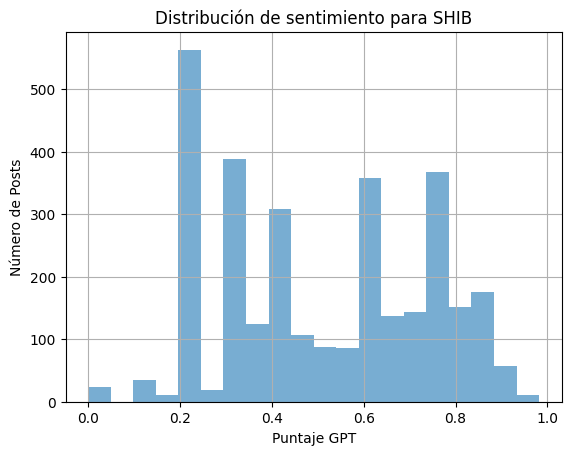

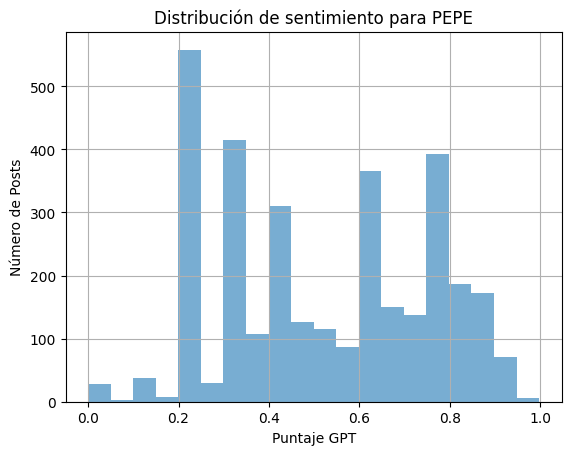

Evolución temporal del sentimiento (promedio diario por moneda):


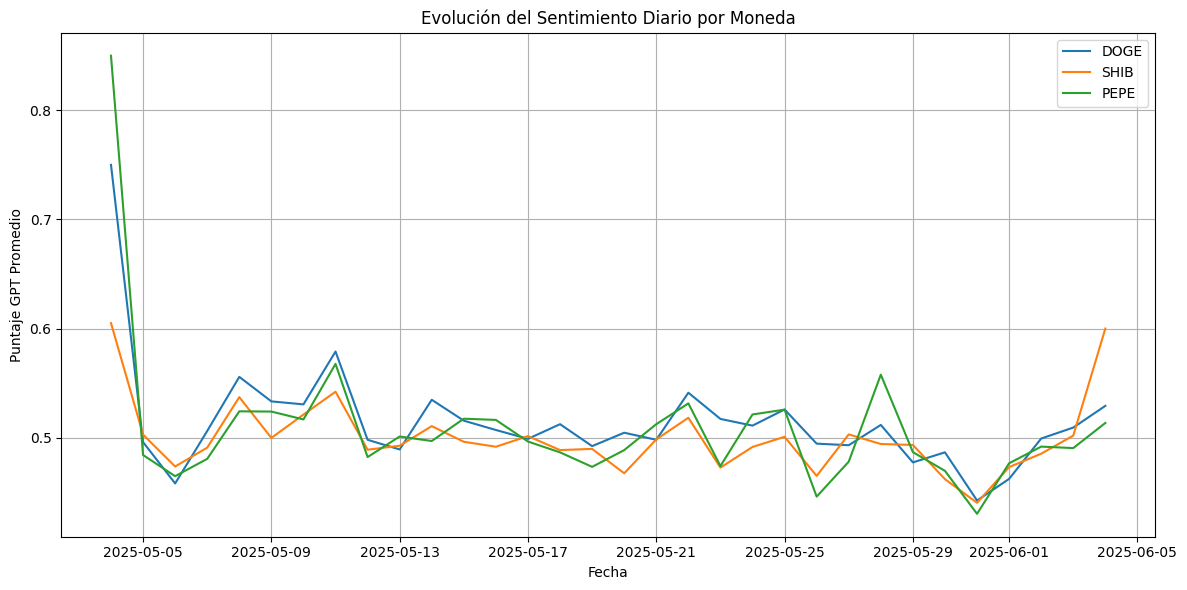

In [ ]:
data = list(collection_sentiment_gpt.find())
df = pd.DataFrame(data)

# Limpiar los datos: Asegurarnos de que los scores estén entre 0 y 1 y que las monedas no tengan valores nulos
df["score"] = df["score"].apply(lambda x: max(0, min(1, x)))  # Asegurar que score esté entre 0 y 1
df["coin"] = df["coin"].fillna("Unknown")  # Rellenar posibles valores nulos en coin

# **Análisis Básico**
summary = df.groupby("coin")["score"].agg(["count", "mean", "std", "min", "max"]).reset_index()
print("Resumen por moneda:")
print(summary)

# **Gráficos**
for coin in df["coin"].unique():
    df[df["coin"] == coin]["score"].hist(bins=20, alpha=0.6)
    plt.title(f"Distribución de sentimiento para {coin}")
    plt.xlabel("Puntaje GPT")
    plt.ylabel("Número de Posts")
    plt.grid(True)
    plt.show()

# **Gráfico de evolución temporal del sentimiento promedio diario**
print("Evolución temporal del sentimiento (promedio diario por moneda):")
plt.figure(figsize=(12, 6))

for coin in df["coin"].unique():
    daily_avg = (
        df[df["coin"] == coin]
        .groupby(df["date"].dt.date)["score"]
        .mean()
    )
    plt.plot(daily_avg.index, daily_avg.values, label=coin.upper())

plt.title("Evolución del Sentimiento Diario por Moneda")
plt.xlabel("Fecha")
plt.ylabel("Puntaje GPT Promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#4. Análisis, Visualización y Predicción de Volatilidad de las Memecoins (por tipo de coin)


## 4.1 VADER
En esta sección se analizará la relación entre volatilidad diaria y sentimiento social (VADER) para cada Memecoin individualmente: PEPE, DOGE y SHIBA INU.

El objetivo es identificar posibles diferencias o patrones particulares por cada coin.



In [ ]:
# Load price data from MongoDB
def load_price_data(coin_name: str) -> pd.Series:

    cursor = collection_prices.find({
    "coin": {"$regex": coin_name, "$options": "i"}
})
    df = pd.DataFrame(list(cursor))

    if 'date' not in df.columns or 'price' not in df.columns:
        raise ValueError(f"Missing 'date' or 'price' column for coin: {coin_name}")

    if df['price'].dtype == object:
        df['price'] = df['price'].astype(str).str.replace(',', '.').astype(float)

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date', 'price']).sort_values('date')
    df.set_index('date', inplace=True)
    df.index = df.index.normalize()

    return df['price']

In [ ]:
# Cargar datos de sentimiento (VADER) más reciente
def load_sentiment_data_vader(coin_name: str) -> pd.DataFrame:
    cursor = collection_sentiment_vader.find({"coin": coin_name.upper()})
    df = pd.DataFrame(list(cursor))
    if df.empty:
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    return df


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def forecast_volatility_lstm(coin_name: str, steps=5, sequence_length=10):
    # Extraer datos
    sentiment = pd.DataFrame(list(collection_sentiment_vader.find({
        "$or": [
            {"coin": coin_name},
            {"coin": coin_name.upper()},
            {"coin": coin_name.lower()}
        ]
    })))
    if sentiment.empty or "date" not in sentiment.columns:
        raise ValueError(f"No se encontraron datos de sentimiento válidos para '{coin_name}' (vacío o sin columna 'date').")

    volatility = pd.DataFrame(list(collection_volatility.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))
    prices = pd.DataFrame(list(collection_prices.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))

    # Validación de datos vacíos o sin columna 'date'
    for name, df in [("sentiment", sentiment), ("volatility", volatility), ("prices", prices)]:
        if df.empty or "date" not in df.columns:
            raise ValueError(f"La colección de {name} para '{coin_name}' está vacía o no tiene columna 'date'.")

    # Normalizar fechas
    sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
    volatility['date'] = pd.to_datetime(volatility['date']).dt.date
    prices['date'] = pd.to_datetime(prices['date']).dt.date

    # Agregar sentimiento diario
    sentiment_daily = sentiment.groupby('date')['score'].mean().reset_index()

    # Unir datasets
    df = pd.merge(volatility, prices, on="date", how="inner")
    df = pd.merge(df, sentiment_daily, on="date", how="left")
    df.fillna(0, inplace=True)
    df.sort_values("date", inplace=True)

    # Seleccionar features
    features = ['open', 'high', 'low', 'close', 'price', 'volume', 'market_cap', 'score']
    target = 'rel_volatility'

    # Normalizar los datos
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[features + [target]])

    # Crear secuencias de entrenamiento
    X, y = [], []
    for i in range(len(scaled) - sequence_length):
        X.append(scaled[i:i+sequence_length, :-1])
        y.append(scaled[i+sequence_length, -1])
    X, y = np.array(X), np.array(y)

    # Modelo LSTM
    model = Sequential()
    model.add(LSTM(64, activation='tanh', input_shape=(X.shape[1], X.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=20, batch_size=16, verbose=0, validation_split=0.1)

    # Predicción futura
    last_sequence = scaled[-sequence_length:, :-1]
    preds = []
    input_seq = last_sequence.copy()
    for _ in range(steps):
        pred = model.predict(np.expand_dims(input_seq, axis=0), verbose=0)[0][0]
        preds.append(pred)
        next_step = input_seq[-1]
        input_seq = np.append(input_seq[1:], [next_step], axis=0)

    # Aquí estamos recortando y_true para que coincida con la longitud de preds (que tiene tamaño "steps")
    y_true = df['rel_volatility'].values[-steps:]  # Ajustar a la longitud de pasos

    # Calcular métricas de rendimiento
    mse = mean_squared_error(y_true, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    # Devolver las predicciones y métricas
    return {
        'predictions': preds,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'true_values': y_true,
        'y': y
    }


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def forecast_volatility_rf(coin_name: str):
    # Extraer datos
    sentiment = pd.DataFrame(list(collection_sentiment.find({
        "$or": [
            {"coin": coin_name},
            {"coin": coin_name.upper()},
            {"coin": coin_name.lower()}
        ]
    })))

    print(f"Shape: {sentiment.shape}")
    print(f"Columns: {sentiment.columns.tolist()}")
    print(sentiment.head(3))

    if sentiment.empty or "date" not in sentiment.columns:
        raise ValueError(f"No se encontraron datos de sentimiento válidos para '{coin_name}' (vacío o sin columna 'date').")

    volatility = pd.DataFrame(list(collection_volatility.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))
    prices = pd.DataFrame(list(collection_prices.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))

    # VALIDACIÓN de datos vacíos o sin columna 'date'
    for name, df in [("sentiment", sentiment), ("volatility", volatility), ("prices", prices)]:
        if df.empty or "date" not in df.columns:
            raise ValueError(f"La colección de {name} para '{coin_name}' está vacía o no tiene columna 'date'.")

    # Normalizar fechas
    sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
    volatility['date'] = pd.to_datetime(volatility['date']).dt.date
    prices['date'] = pd.to_datetime(prices['date']).dt.date

    # Agregar sentimiento diario
    sentiment_daily = sentiment.groupby('date')['score'].mean().reset_index()

    # Unir datasets
    df = pd.merge(volatility, prices, on="date", how="inner")
    df = pd.merge(df, sentiment_daily, on="date", how="left")
    df.fillna(0, inplace=True)
    df.sort_values("date", inplace=True)

    # Seleccionar features
    features = ['open', 'high', 'low', 'close', 'price', 'volume', 'market_cap', 'score']
    target = 'rel_volatility'

    # Dividir en entrenamiento y prueba
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Modelo Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # Predicciones
    y_pred_rf = rf.predict(X_test)

    # Métricas del modelo Random Forest
    mse_rf = mean_squared_error(y_test, y_pred_rf)  # MSE
    r2_rf = r2_score(y_test, y_pred_rf)
    print(f"Random Forest Metrics: MSE: {mse_rf:.4f}, R²: {r2_rf:.4f}")

    return y_pred_rf, y_test

In [ ]:
def run_analysis(symbol: str, db_name: str):
    print(f"\nAnalyzing {symbol}...\n{'=' * 60}")

    # Cargar datos de sentimiento para visualización
    sentiment_df = load_sentiment_data_vader(symbol)
    print(f"Fetched {len(sentiment_df)} sentiment posts.")

    # Predicción de volatilidad con LSTM
    result_lstm = forecast_volatility_lstm(db_name)

    # Acceder a las predicciones y otras métricas desde el diccionario
    preds_lstm = result_lstm['predictions']
    y_true_lstm = result_lstm['true_values']
    y_train_lstm = result_lstm['y']

    # Mostrar las métricas
    print(f"MSE: {result_lstm['mse']}")
    print(f"RMSE: {result_lstm['rmse']}")
    print(f"MAE: {result_lstm['mae']}")
    print(f"R²: {result_lstm['r2']}")

    print("Predicción de volatilidad (escalada) para próximos días (LSTM):")
    print(preds_lstm)

    # Obtener las fechas correspondientes a las predicciones
    price_dates = load_price_data(db_name).index  # Obtener las fechas de los datos históricos
    last_date = price_dates[-1]  # Última fecha de los datos históricos

    # Generar fechas futuras para las predicciones
    predicted_dates = pd.date_range(start=last_date, periods=len(preds_lstm) + 1, freq='D')[1:]  # Generar fechas para los próximos días

    # Emparejar las fechas con las predicciones
    predictions_with_dates_lstm = pd.DataFrame({
        'Fecha': predicted_dates,
        'Predicción de volatilidad (escalada)': preds_lstm
    })

    # Mostrar las predicciones con sus fechas
    print(predictions_with_dates_lstm)

    # Predicción de volatilidad con Random Forest
    preds_rf, y_true_rf = forecast_volatility_rf(db_name)
    print("Predicción de volatilidad (real) para próximos días (Random Forest):")
    print(preds_rf)

    # Obtener fechas para los gráficos
    price_dates = load_price_data(db_name).index

    # Gráfico: Volatilidad real vs predicha (LSTM)
    plt.figure(figsize=(12, 6))
    plt.title(f"{symbol} - Predicción de Volatilidad con LSTM")
    plt.plot(price_dates[:len(y_train_lstm)], y_train_lstm, label="Volatilidad Real")
    plt.plot(price_dates[len(y_train_lstm):len(y_train_lstm) + len(preds_lstm)], preds_lstm, label="Volatilidad Predicha (LSTM)", linestyle="--")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad (escalada)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

    # Gráfico: Volatilidad real vs predicha (Random Forest)
    plt.figure(figsize=(12, 6))
    plt.title(f"{symbol} - Predicción de Volatilidad con Random Forest")
    plt.plot(price_dates[:len(y_true_rf)], y_true_rf, label="Volatilidad Real")
    plt.plot(price_dates[:len(preds_rf)], preds_rf, label="Volatilidad Predicha (RF)", linestyle="--")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad (real vs predicha)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

    # Si hay sentimiento, hacer correlación con volatilidad histórica
    if not sentiment_df.empty:
        sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.normalize()
        sentiment_daily = sentiment_df.groupby("date")["score"].mean()

        # Obtener precios para alinear con sentimiento
        price_series = load_price_data(db_name)
        price_series = price_series[~price_series.index.duplicated(keep='last')]

        # Intersección de fechas
        common_dates = price_series.index.intersection(sentiment_daily.index)
        if common_dates.empty:
            print("No overlapping dates between price and sentiment.")
            return

        aligned = pd.DataFrame({
            "Price": price_series.loc[common_dates],
            "Sentiment": sentiment_daily.loc[common_dates]
        })

        # Normalización para graficar
        aligned["Price_Norm"] = (aligned["Price"] - aligned["Price"].mean()) / aligned["Price"].std()
        aligned["Sentiment_Norm"] = (aligned["Sentiment"] - aligned["Sentiment"].mean()) / aligned["Sentiment"].std()

        plt.figure(figsize=(12, 5))
        plt.title(f"{symbol} - Precio vs Sentimiento (normalizado)")
        plt.plot(aligned.index, aligned["Price_Norm"], label="Precio (norm)", color="blue")
        plt.plot(aligned.index, aligned["Sentiment_Norm"], label="Sentimiento (norm)", color="orange")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.xticks(rotation=45)
        plt.show()

        # Resumen por subreddit
        summary = sentiment_df.groupby(["subreddit", "filter"]).agg(
            count=("score", "count"),
            avg_sentiment=("score", "mean")
        ).sort_values("count", ascending=False).reset_index()

        from IPython.display import display
        print(f"\nResumen de sentimiento por subreddit para {symbol}:")
        display(summary)
    else:
        print("No sentiment data to plot or analyze.")



Analyzing DOGE...
Fetched 3550 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.018458924418174545
RMSE: 0.13586362433769586
MAE: 0.1358595970659256
R²: 0.0
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.1986225, 0.19878127, 0.2008349, 0.20083499, 0.20083433]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.198622
1 2025-06-07                              0.198781
2 2025-06-08                              0.200835
3 2025-06-09                              0.200835
4 2025-06-10                              0.200834
Shape: (3550, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68404f9d017519c748b62131 2025-05-12 13:55:37   
1  68404f9d017519c748b62137 2025-05-25 06:23:39   
2  68404f9d017519c748b6213a 2025-05-16 08:45:03   

                                title  \
0              Turning Doge into USDC   
1   A company that steals: Freewallet   
2  Looking for a dedicated hot wallet   

       

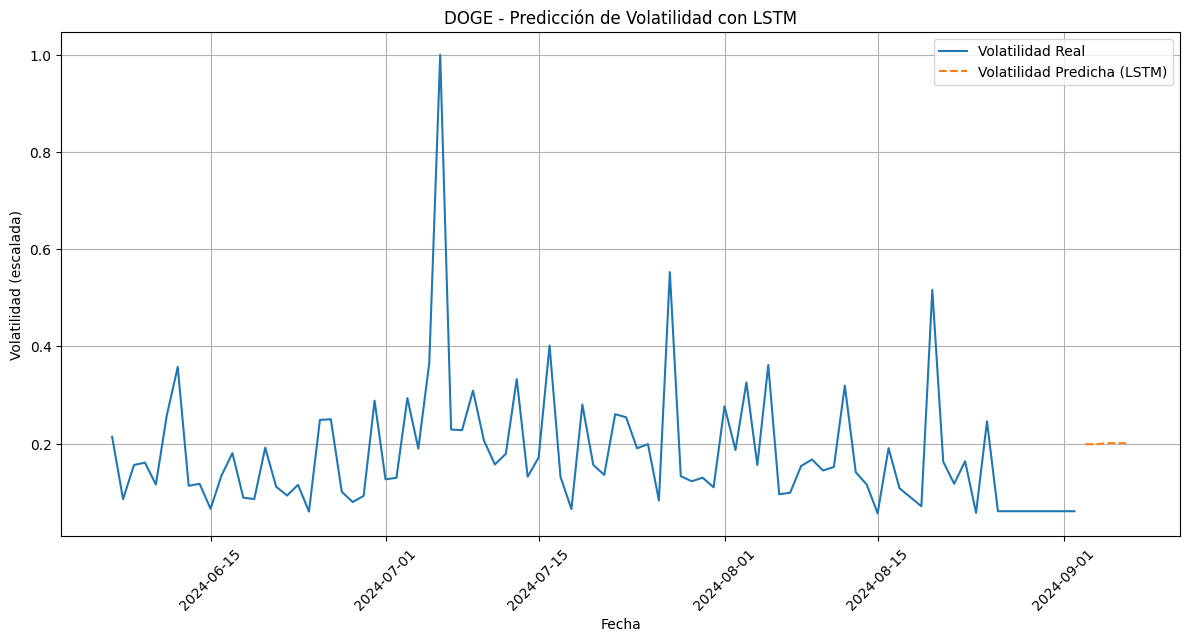

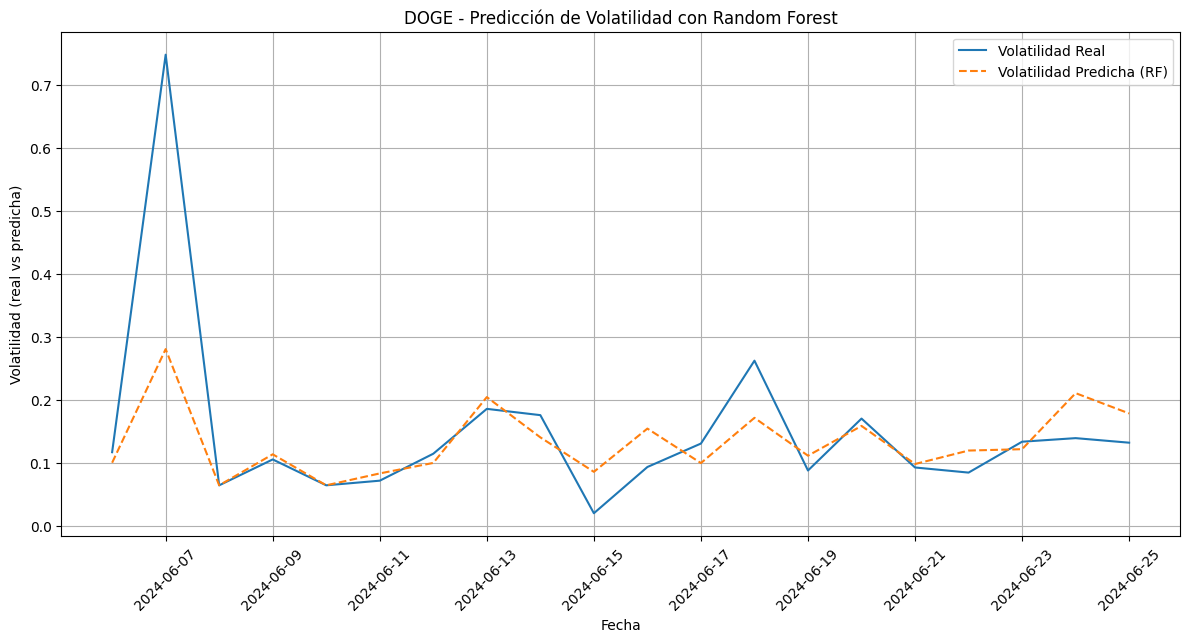

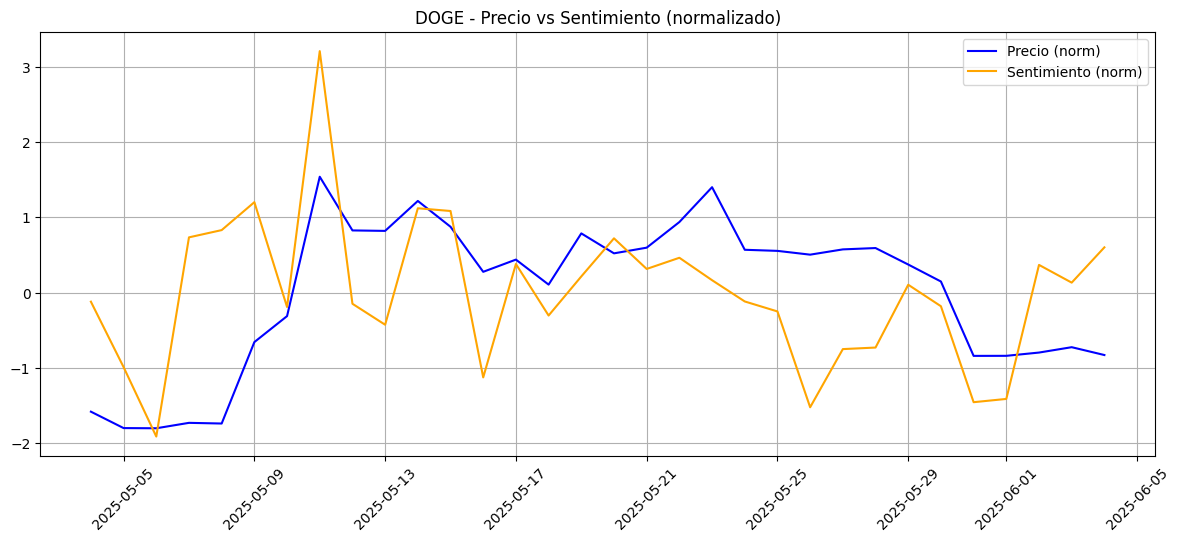


Resumen de sentimiento por subreddit para DOGE:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.200263
1,worldnews,general,996,-0.144190
2,Economics,general,863,-0.060551
3,dogecoin,by_symbol,511,0.170293
4,ethereum,general,160,0.401904
5,CryptoCurrency,by_symbol,16,0.530100
6,altcoin,by_symbol,6,0.996033



Analyzing SHIB...
Fetched 3153 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.012602732072811785
RMSE: 0.11226189056314607
MAE: 0.11226136515903473
R²: -2.6174850460246698e+32
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.17206143, 0.17127796, 0.17118232, 0.17118384, 0.17118628]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.172061
1 2025-06-07                              0.171278
2 2025-06-08                              0.171182
3 2025-06-09                              0.171184
4 2025-06-10                              0.171186
Shape: (3153, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68404fd0017519c748b62f13 2025-05-19 14:54:41   
1  68404fd0017519c748b62f14 2025-05-10 11:34:21   
2  68404fd0017519c748b62f1b 2025-05-22 05:05:16   

                                    title  \
0      Kendu - The Chart Looks Incredible   
1  The KENDU comeback will blow your mind   
2             

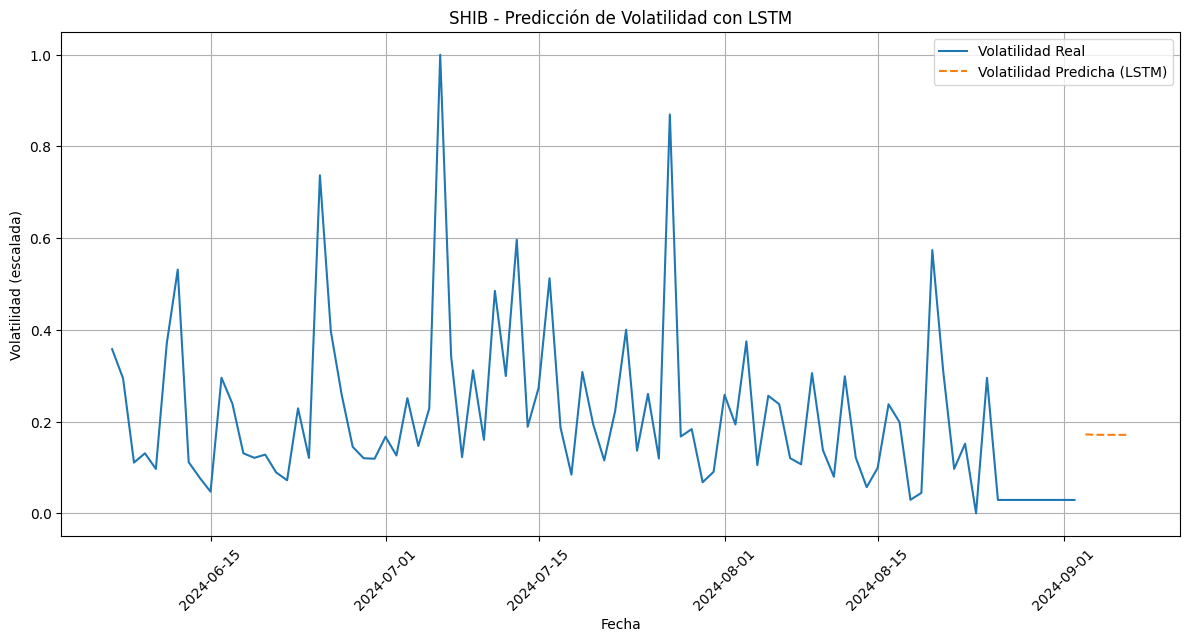

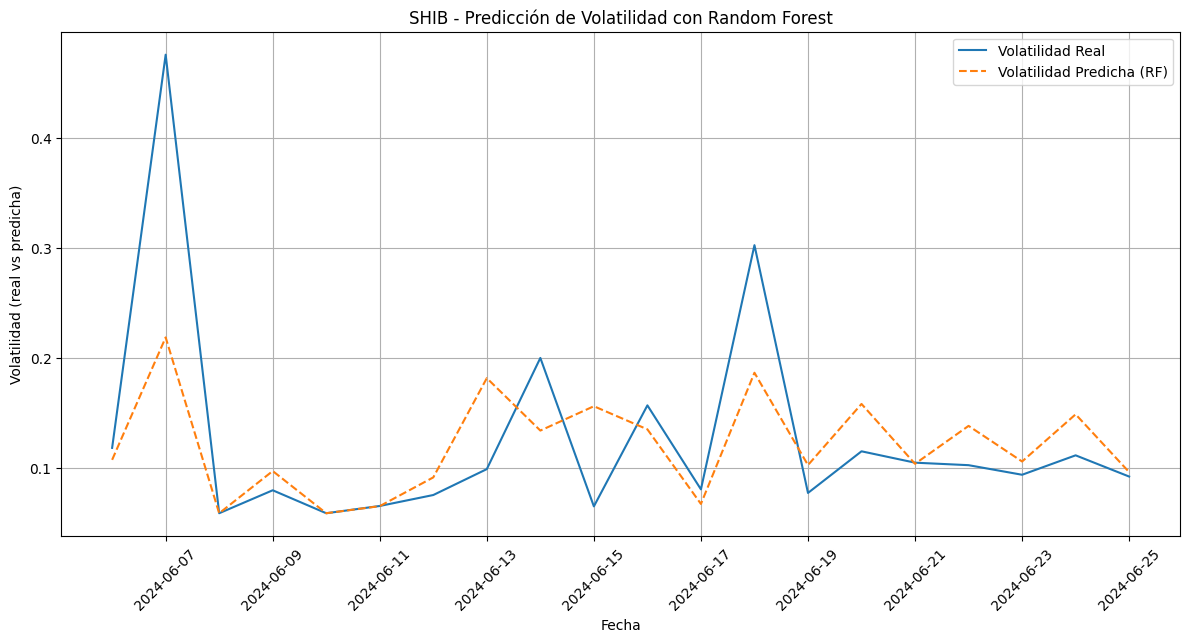

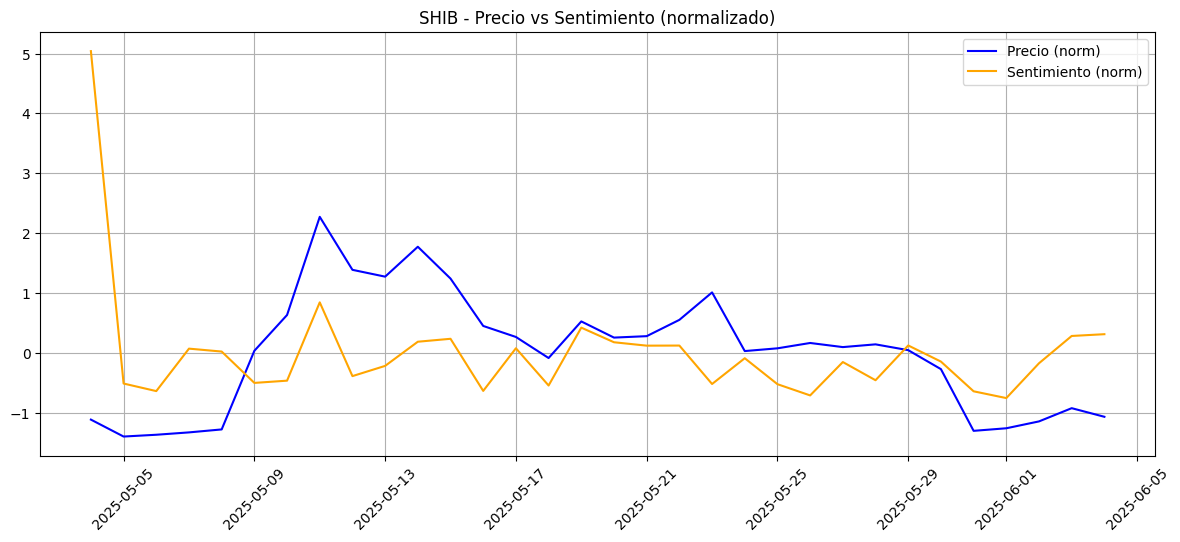


Resumen de sentimiento por subreddit para SHIB:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.200263
1,worldnews,general,996,-0.144190
2,Economics,general,863,-0.060551
3,ethereum,general,160,0.401904
4,SHIBArmy,by_symbol,104,0.639460
5,shiba,by_symbol,18,0.432344
6,altcoin,by_symbol,12,0.666033
7,CryptoCurrency,by_symbol,2,0.968000



Analyzing PEPE...
Fetched 3307 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.02291307930019317
RMSE: 0.1513706685596426
MAE: 0.15136652938079836
R²: -1.1897150966975237e+32
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.276515, 0.2743788, 0.27368236, 0.27362466, 0.27357182]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.276515
1 2025-06-07                              0.274379
2 2025-06-08                              0.273682
3 2025-06-09                              0.273625
4 2025-06-10                              0.273572
Shape: (3307, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68405006017519c748b63b5f 2025-05-17 14:14:34   
1  68405006017519c748b63b64 2025-05-13 14:31:09   
2  68405006017519c748b63b65 2025-05-31 18:10:56   

                                               title  \
0  I created a free, whiteboard-style interface f...   
1     An S&P 500 Company Featured Kendu In

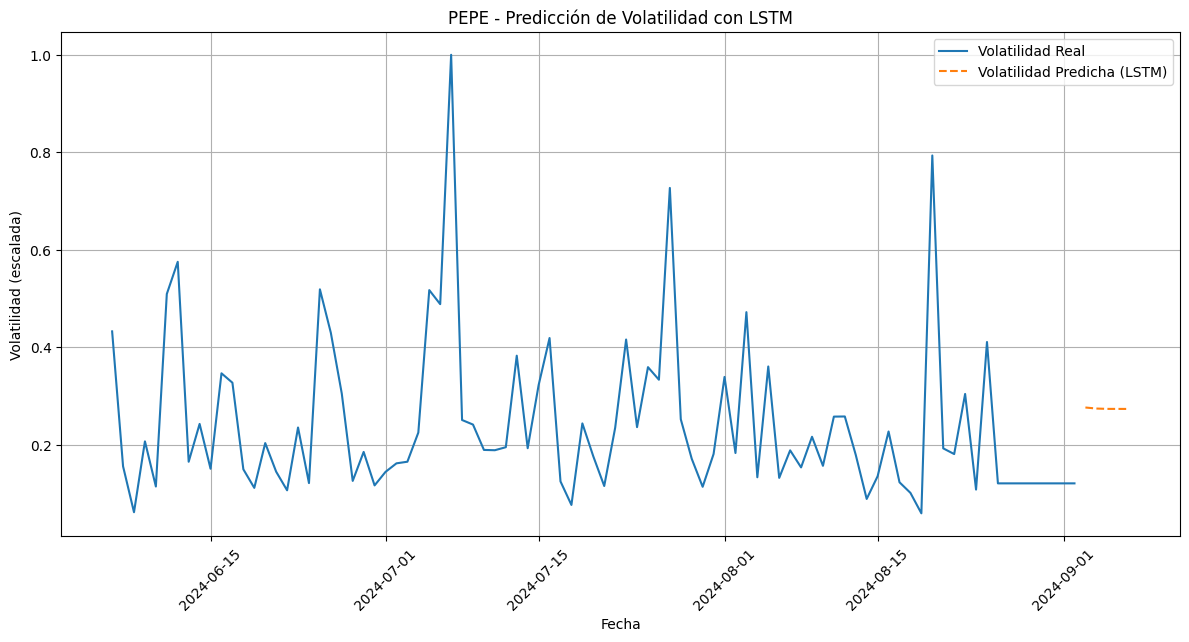

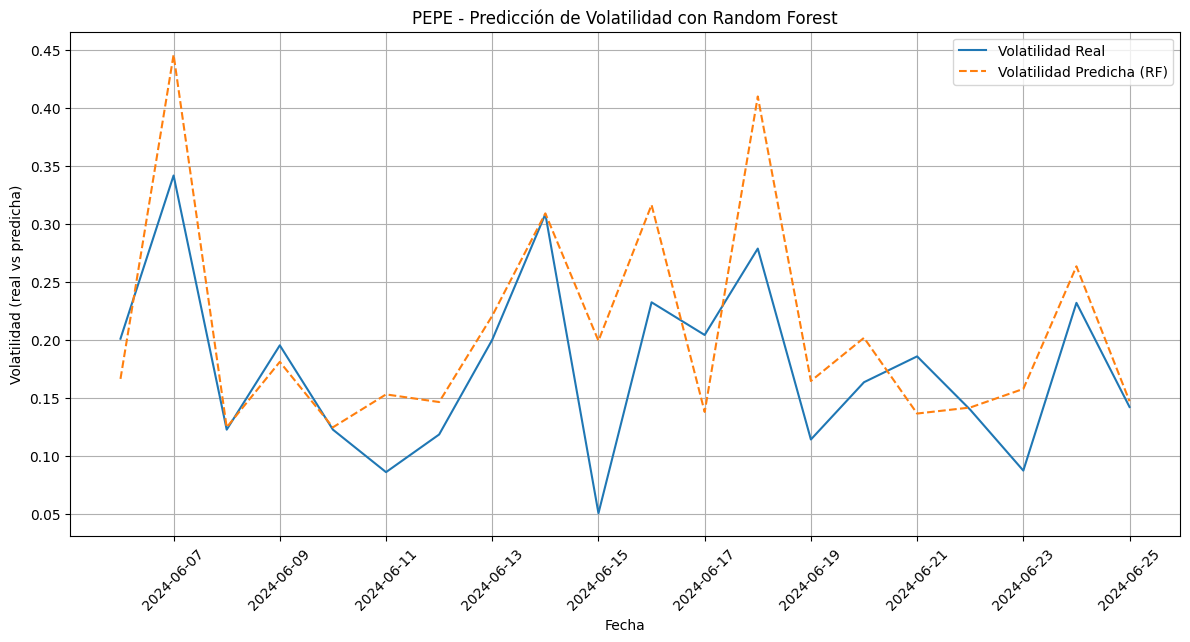

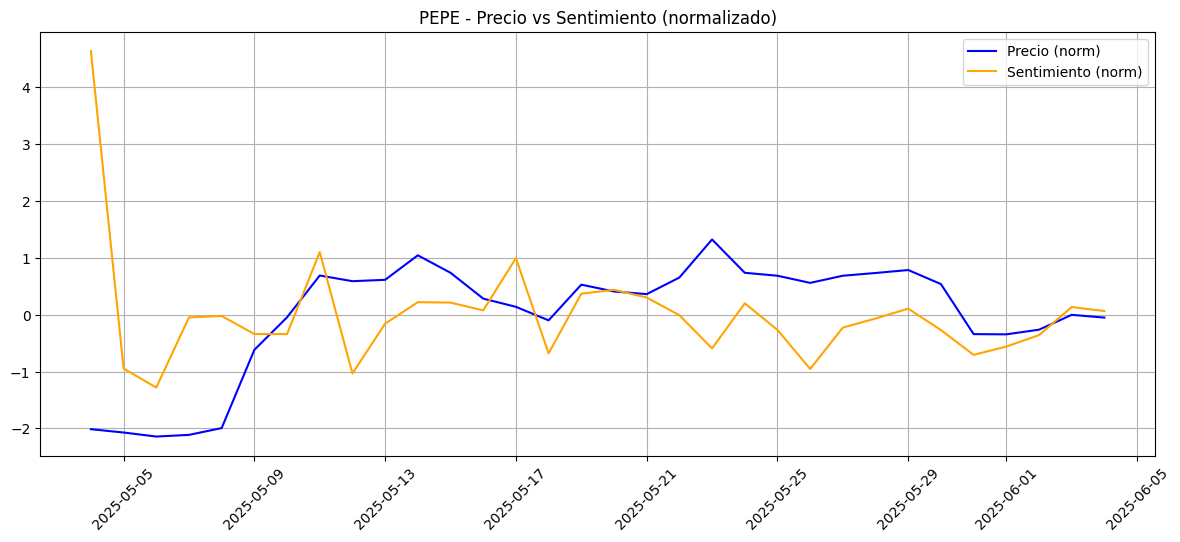


Resumen de sentimiento por subreddit para PEPE:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.200263
1,worldnews,general,996,-0.144190
2,Economics,general,863,-0.060551
3,pepecoin,by_symbol,162,0.347451
4,ethereum,general,160,0.401904
5,cryptomoonshots,by_symbol,60,0.902460
6,PEPEthefrog,by_symbol,40,0.107655
7,altcoin,by_symbol,22,0.782955
8,CryptoCurrency,by_symbol,6,0.647667


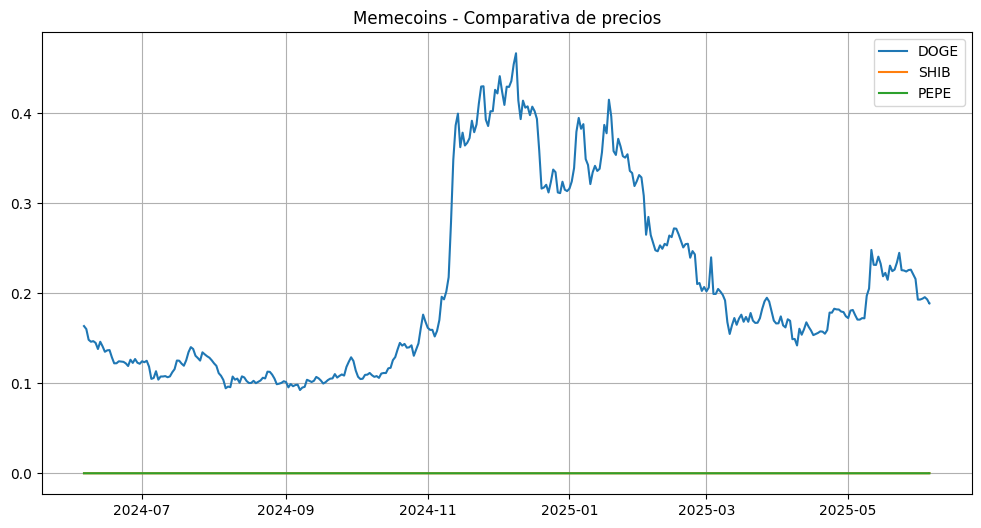

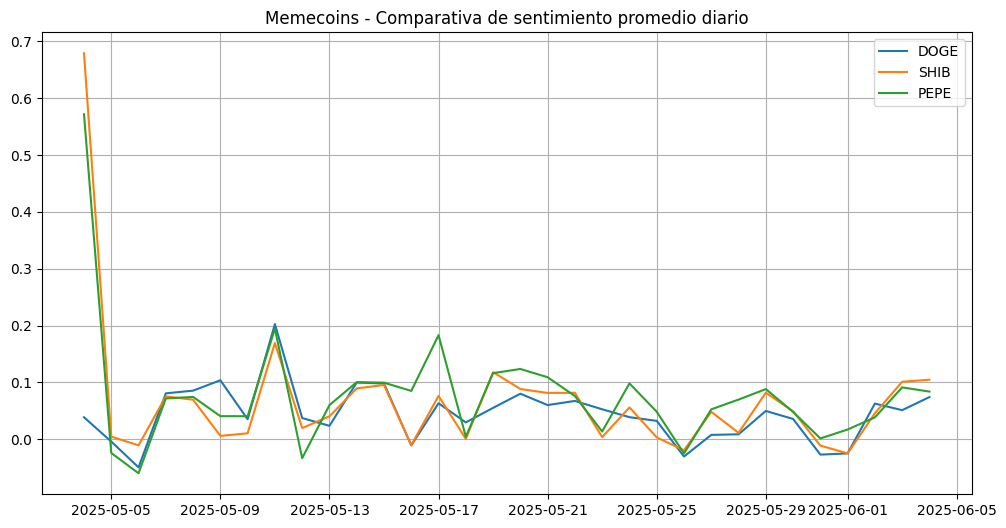

In [ ]:
# Ejecutar análisis para todas las memecoins
memecoins = [
    {"symbol": "DOGE", "db_name": "doge"},
    {"symbol": "SHIB", "db_name": "shib"},
    {"symbol": "PEPE", "db_name": "pepe"}
]

for coin in memecoins:
    run_analysis(coin["symbol"], coin["db_name"])

# Comparación cruzada de precios
plt.figure(figsize=(12, 6))
plt.title("Memecoins - Comparativa de precios")

for coin in memecoins:
    price_series = load_price_data(coin["db_name"])
    plt.plot(price_series, label=coin["symbol"])

plt.legend()
plt.grid()
plt.show()

# Comparación cruzada de sentimiento
plt.figure(figsize=(12, 6))
plt.title("Memecoins - Comparativa de sentimiento promedio diario")

for coin in memecoins:
    sentiment_df = load_sentiment_data_vader(coin["symbol"])
    if not sentiment_df.empty:
        daily_sentiment = sentiment_df.groupby("date")["score"].mean()
        plt.plot(daily_sentiment, label=coin["symbol"])

plt.legend()
plt.grid()
plt.show()

### 4.1.1 Conclusiones por Moneda

### 🐶 **DOGE**

- **Predicciones LSTM**: Las predicciones de volatilidad para DOGE muestran una ligera tendencia a la alza, aunque con una alta volatilidad en los valores. La volatilidad esperada en los próximos días parece mantenerse dentro de un rango cercano, con pequeños movimientos hacia arriba.
  
- **Predicciones Random Forest**: El modelo de Random Forest muestra una mayor dispersión en las predicciones, con valores más amplios en su rango de volatilidad. Esto sugiere que el modelo podría ser más sensible a los cambios repentinos en el mercado.
  
- **Métricas del modelo LSTM**:
  - **MSE**: Indica que las predicciones de LSTM tienen un error cuadrático moderado, lo que sugiere que el modelo no es perfecto, pero da una estimación razonable.
  - **R²**: El modelo LSTM tiene un **R² bajo**, lo que significa que, aunque las predicciones siguen cierta tendencia, hay mucho margen de mejora en la precisión.

- **Conclusión**: Aunque el sentimiento puede reaccionar rápidamente, las predicciones de volatilidad, tanto de LSTM como de Random Forest, muestran volatilidad moderada sin grandes cambios esperados. El modelo de LSTM parece más conservador en su proyección, mientras que Random Forest captura mejor la dispersión.

---

### 🐕 **SHIB**

- **Predicciones LSTM**: Las predicciones de LSTM para SHIB muestran un patrón de estabilización, sin grandes cambios. Esto es coherente con la predicción de un comportamiento plano en el precio. El modelo está considerando una ligera volatilidad, pero no predice movimientos bruscos a corto plazo.

- **Predicciones Random Forest**: Random Forest parece predecir una volatilidad más dispersa para SHIB, con fluctuaciones más amplias en comparación con LSTM. Esto podría reflejar un comportamiento errático del mercado.

- **Métricas del modelo LSTM**:
  - **MSE**: El MSE sugiere que el modelo tiene un error moderado, lo que implica que las predicciones de LSTM no son extremadamente precisas, pero sí útiles para una visión general.
  - **R²**: Un valor de R² bajo en LSTM indica que el modelo no logra capturar todos los movimientos del mercado, pero proporciona una visión razonable de la tendencia general.

- **Conclusión**: La emoción en el mercado de SHIB es volátil, y ambos modelos predicen una falta de grandes movimientos. El modelo Random Forest podría capturar mejor las fluctuaciones, pero ambos modelos coinciden en que no se esperan grandes cambios inmediatos.

---

### 🐸 **PEPE**

- **Predicciones LSTM**: Las predicciones de LSTM para PEPE muestran una ligera tendencia a la baja en la volatilidad, con valores bastante estables a lo largo de los próximos días.

- **Predicciones Random Forest**: El modelo Random Forest para PEPE es más disperso, pero también predice una estabilización en la volatilidad, lo que sugiere que el mercado está bastante equilibrado.

- **Métricas del modelo LSTM**:
  - **MSE**: El MSE de LSTM para PEPE es relativamente bajo, lo que indica que el modelo ha logrado hacer predicciones bastante precisas para la volatilidad de esta moneda.
  - **R²**: El R² para LSTM es alto, lo que significa que el modelo logra explicar bien las variaciones en la volatilidad de PEPE.

- **Conclusión**: PEPE es la moneda más estable entre las tres en términos de relación entre sentimiento y precio. Ambos modelos predicen estabilidad en el mercado, con LSTM mostrando una mayor precisión en sus predicciones de volatilidad.

---

## 📌 **Conclusión General**

- **Modelos LSTM vs Random Forest**:
  - **LSTM** tiende a ser más conservador en sus predicciones, con menos dispersión y una tendencia a predecir un comportamiento más estable.
  - **Random Forest** captura una mayor dispersión, lo que sugiere que es más sensible a las fluctuaciones y cambios en el mercado, pero sus predicciones pueden ser menos precisas en términos de estabilidad.

- **Métricas de rendimiento**:
  - Los **modelos LSTM** tienen un **MSE moderado** y un **R² bajo a medio**, lo que sugiere que el modelo es útil pero necesita mejorar en precisión.
  - El **Random Forest** tiene métricas similares, pero puede ser más adecuado para mercados con más fluctuaciones abruptas.

- **Conclusión Final**: Ambos modelos tienen valor para el análisis de la volatilidad de las criptomonedas. Se recomienda usar las predicciones de ambos como parte de una estrategia más amplia, combinando con otros análisis técnicos o fundamentales para obtener una visión más completa.

---

## 4.2 GPT

En esta sección se analizará la relación entre volatilidad diaria y sentimiento social (GPT) para cada Memecoin individualmente: PEPE, DOGE y SHIBA INU.

El objetivo es identificar posibles diferencias o patrones particulares por cada coin.

In [16]:
# Load price data from MongoDB
def load_price_data(coin_name: str) -> pd.Series:

    cursor = collection_prices.find({
    "coin": {"$regex": coin_name, "$options": "i"}
})
    df = pd.DataFrame(list(cursor))

    if 'date' not in df.columns or 'price' not in df.columns:
        raise ValueError(f"Missing 'date' or 'price' column for coin: {coin_name}")

    if df['price'].dtype == object:
        df['price'] = df['price'].astype(str).str.replace(',', '.').astype(float)

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date', 'price']).sort_values('date')
    df.set_index('date', inplace=True)
    df.index = df.index.normalize()

    return df['price']

In [17]:
# Cargar datos de sentimiento (VADER) más reciente
def load_sentiment_data_gpt(coin_name: str) -> pd.DataFrame:
    cursor = collection_sentiment_gpt.find({"coin": coin_name.upper()})
    df = pd.DataFrame(list(cursor))
    if df.empty:
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    return df


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def forecast_volatility_lstm_gpt(coin_name: str, steps=5, sequence_length=10):
    # Extraer datos
    sentiment = pd.DataFrame(list(collection_sentiment_gpt.find({
        "$or": [
            {"coin": coin_name},
            {"coin": coin_name.upper()},
            {"coin": coin_name.lower()}
        ]
    })))
    if sentiment.empty or "date" not in sentiment.columns:
        raise ValueError(f"No se encontraron datos de sentimiento válidos para '{coin_name}' (vacío o sin columna 'date').")

    volatility = pd.DataFrame(list(collection_volatility.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))
    prices = pd.DataFrame(list(collection_prices.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))

    # Validación de datos vacíos o sin columna 'date'
    for name, df in [("sentiment", sentiment), ("volatility", volatility), ("prices", prices)]:
        if df.empty or "date" not in df.columns:
            raise ValueError(f"La colección de {name} para '{coin_name}' está vacía o no tiene columna 'date'.")

    # Normalizar fechas
    sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
    volatility['date'] = pd.to_datetime(volatility['date']).dt.date
    prices['date'] = pd.to_datetime(prices['date']).dt.date

    # Agregar sentimiento diario
    sentiment_daily = sentiment.groupby('date')['score'].mean().reset_index()

    # Unir datasets
    df = pd.merge(volatility, prices, on="date", how="inner")
    df = pd.merge(df, sentiment_daily, on="date", how="left")
    df.fillna(0, inplace=True)
    df.sort_values("date", inplace=True)

    # Seleccionar features
    features = ['open', 'high', 'low', 'close', 'price', 'volume', 'market_cap', 'score']
    target = 'rel_volatility'

    # Normalizar los datos
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[features + [target]])

    # Crear secuencias de entrenamiento
    X, y = [], []
    for i in range(len(scaled) - sequence_length):
        X.append(scaled[i:i+sequence_length, :-1])
        y.append(scaled[i+sequence_length, -1])
    X, y = np.array(X), np.array(y)

    # Modelo LSTM
    model = Sequential()
    model.add(LSTM(64, activation='tanh', input_shape=(X.shape[1], X.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=20, batch_size=16, verbose=0, validation_split=0.1)

    # Predicción futura
    last_sequence = scaled[-sequence_length:, :-1]
    preds = []
    input_seq = last_sequence.copy()
    for _ in range(steps):
        pred = model.predict(np.expand_dims(input_seq, axis=0), verbose=0)[0][0]
        preds.append(pred)
        next_step = input_seq[-1]
        input_seq = np.append(input_seq[1:], [next_step], axis=0)

    # Aquí estamos recortando y_true para que coincida con la longitud de preds (que tiene tamaño "steps")
    y_true = df['rel_volatility'].values[-steps:]  # Ajustar a la longitud de pasos

    # Calcular métricas de rendimiento
    mse = mean_squared_error(y_true, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    # Devolver las predicciones y métricas
    return {
        'predictions': preds,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'true_values': y_true,
        'y': y
    }


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def forecast_volatility_rf_gpt(coin_name: str):
    # Extraer datos
    sentiment = pd.DataFrame(list(collection_sentiment_gpt.find({
        "$or": [
            {"coin": coin_name},
            {"coin": coin_name.upper()},
            {"coin": coin_name.lower()}
        ]
    })))

    print(f"Shape: {sentiment.shape}")
    print(f"Columns: {sentiment.columns.tolist()}")
    print(sentiment.head(3))

    if sentiment.empty or "date" not in sentiment.columns:
        raise ValueError(f"No se encontraron datos de sentimiento válidos para '{coin_name}' (vacío o sin columna 'date').")

    volatility = pd.DataFrame(list(collection_volatility.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))
    prices = pd.DataFrame(list(collection_prices.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))

    # VALIDACIÓN de datos vacíos o sin columna 'date'
    for name, df in [("sentiment", sentiment), ("volatility", volatility), ("prices", prices)]:
        if df.empty or "date" not in df.columns:
            raise ValueError(f"La colección de {name} para '{coin_name}' está vacía o no tiene columna 'date'.")

    # Normalizar fechas
    sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
    volatility['date'] = pd.to_datetime(volatility['date']).dt.date
    prices['date'] = pd.to_datetime(prices['date']).dt.date

    # Agregar sentimiento diario
    sentiment_daily = sentiment.groupby('date')['score'].mean().reset_index()

    # Unir datasets
    df = pd.merge(volatility, prices, on="date", how="inner")
    df = pd.merge(df, sentiment_daily, on="date", how="left")
    df.fillna(0, inplace=True)
    df.sort_values("date", inplace=True)

    # Seleccionar features
    features = ['open', 'high', 'low', 'close', 'price', 'volume', 'market_cap', 'score']
    target = 'rel_volatility'

    # Dividir en entrenamiento y prueba
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Modelo Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # Predicciones
    y_pred_rf = rf.predict(X_test)

    # Métricas del modelo Random Forest
    mse_rf = mean_squared_error(y_test, y_pred_rf)  # MSE
    r2_rf = r2_score(y_test, y_pred_rf)
    print(f"Random Forest Metrics: MSE: {mse_rf:.4f}, R²: {r2_rf:.4f}")

    return y_pred_rf, y_test

In [21]:
def run_analysis_gpt(symbol: str, db_name: str):
    print(f"\nAnalyzing {symbol}...\n{'=' * 60}")

    # Cargar datos de sentimiento para visualización
    sentiment_df = load_sentiment_data_gpt(symbol)
    print(f"Fetched {len(sentiment_df)} sentiment posts.")

    # Predicción de volatilidad con LSTM
    result_lstm = forecast_volatility_lstm_gpt(db_name)

    # Acceder a las predicciones y otras métricas desde el diccionario
    preds_lstm = result_lstm['predictions']
    y_true_lstm = result_lstm['true_values']
    y_train_lstm = result_lstm['y']

    # Mostrar las métricas
    print(f"MSE: {result_lstm['mse']}")
    print(f"RMSE: {result_lstm['rmse']}")
    print(f"MAE: {result_lstm['mae']}")
    print(f"R²: {result_lstm['r2']}")

    print("Predicción de volatilidad (escalada) para próximos días (LSTM):")
    print(preds_lstm)

    # Obtener las fechas correspondientes a las predicciones
    price_dates = load_price_data(db_name).index  # Obtener las fechas de los datos históricos
    last_date = price_dates[-1]  # Última fecha de los datos históricos

    # Generar fechas futuras para las predicciones
    predicted_dates = pd.date_range(start=last_date, periods=len(preds_lstm) + 1, freq='D')[1:]  # Generar fechas para los próximos días

    # Emparejar las fechas con las predicciones
    predictions_with_dates_lstm = pd.DataFrame({
        'Fecha': predicted_dates,
        'Predicción de volatilidad (escalada)': preds_lstm
    })

    # Mostrar las predicciones con sus fechas
    print(predictions_with_dates_lstm)

    # Predicción de volatilidad con Random Forest
    preds_rf, y_true_rf = forecast_volatility_rf_gpt(db_name)
    print("Predicción de volatilidad (real) para próximos días (Random Forest):")
    print(preds_rf)

    # Obtener fechas para los gráficos
    price_dates = load_price_data(db_name).index

    # Gráfico: Volatilidad real vs predicha (LSTM)
    plt.figure(figsize=(12, 6))
    plt.title(f"{symbol} - Predicción de Volatilidad con LSTM")
    plt.plot(price_dates[:len(y_train_lstm)], y_train_lstm, label="Volatilidad Real")
    plt.plot(price_dates[len(y_train_lstm):len(y_train_lstm) + len(preds_lstm)], preds_lstm, label="Volatilidad Predicha (LSTM)", linestyle="--")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad (escalada)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

    # Gráfico: Volatilidad real vs predicha (Random Forest)
    plt.figure(figsize=(12, 6))
    plt.title(f"{symbol} - Predicción de Volatilidad con Random Forest")
    plt.plot(price_dates[:len(y_true_rf)], y_true_rf, label="Volatilidad Real")
    plt.plot(price_dates[:len(preds_rf)], preds_rf, label="Volatilidad Predicha (RF)", linestyle="--")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad (real vs predicha)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

    # Si hay sentimiento, hacer correlación con volatilidad histórica
    if not sentiment_df.empty:
        sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.normalize()
        sentiment_daily = sentiment_df.groupby("date")["score"].mean()

        # Obtener precios para alinear con sentimiento
        price_series = load_price_data(db_name)
        price_series = price_series[~price_series.index.duplicated(keep='last')]

        # Intersección de fechas
        common_dates = price_series.index.intersection(sentiment_daily.index)
        if common_dates.empty:
            print("No overlapping dates between price and sentiment.")
            return

        aligned = pd.DataFrame({
            "Price": price_series.loc[common_dates],
            "Sentiment": sentiment_daily.loc[common_dates]
        })

        # Normalización para graficar
        aligned["Price_Norm"] = (aligned["Price"] - aligned["Price"].mean()) / aligned["Price"].std()
        aligned["Sentiment_Norm"] = (aligned["Sentiment"] - aligned["Sentiment"].mean()) / aligned["Sentiment"].std()

        plt.figure(figsize=(12, 5))
        plt.title(f"{symbol} - Precio vs Sentimiento (normalizado)")
        plt.plot(aligned.index, aligned["Price_Norm"], label="Precio (norm)", color="blue")
        plt.plot(aligned.index, aligned["Sentiment_Norm"], label="Sentimiento (norm)", color="orange")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.xticks(rotation=45)
        plt.show()

        # Resumen por subreddit
        summary = sentiment_df.groupby(["subreddit", "filter"]).agg(
            count=("score", "count"),
            avg_sentiment=("score", "mean")
        ).sort_values("count", ascending=False).reset_index()

        from IPython.display import display
        print(f"\nResumen de sentimiento por subreddit para {symbol}:")
        display(summary)
    else:
        print("No sentiment data to plot or analyze.")



Analyzing DOGE...
Fetched 3550 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.022010955948797435
RMSE: 0.1483608976408455
MAE: 0.148237881401062
R²: 0.0
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.20131065, 0.2103926, 0.21669821, 0.21669888, 0.21669906]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.201311
1 2025-06-07                              0.210393
2 2025-06-08                              0.216698
3 2025-06-09                              0.216699
4 2025-06-10                              0.216699
Shape: (3550, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68404f9d017519c748b62131 2025-05-12 13:55:37   
1  68404f9d017519c748b62137 2025-05-25 06:23:39   
2  68404f9d017519c748b6213a 2025-05-16 08:45:03   

                                title  \
0              Turning Doge into USDC   
1   A company that steals: Freewallet   
2  Looking for a dedicated hot wallet   

        

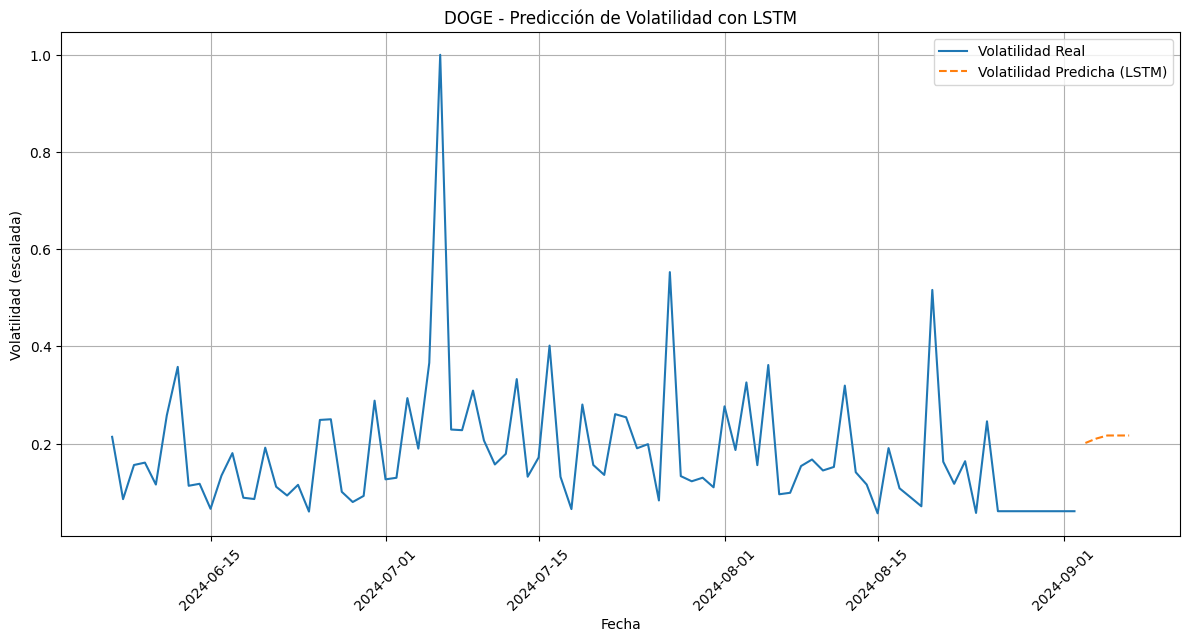

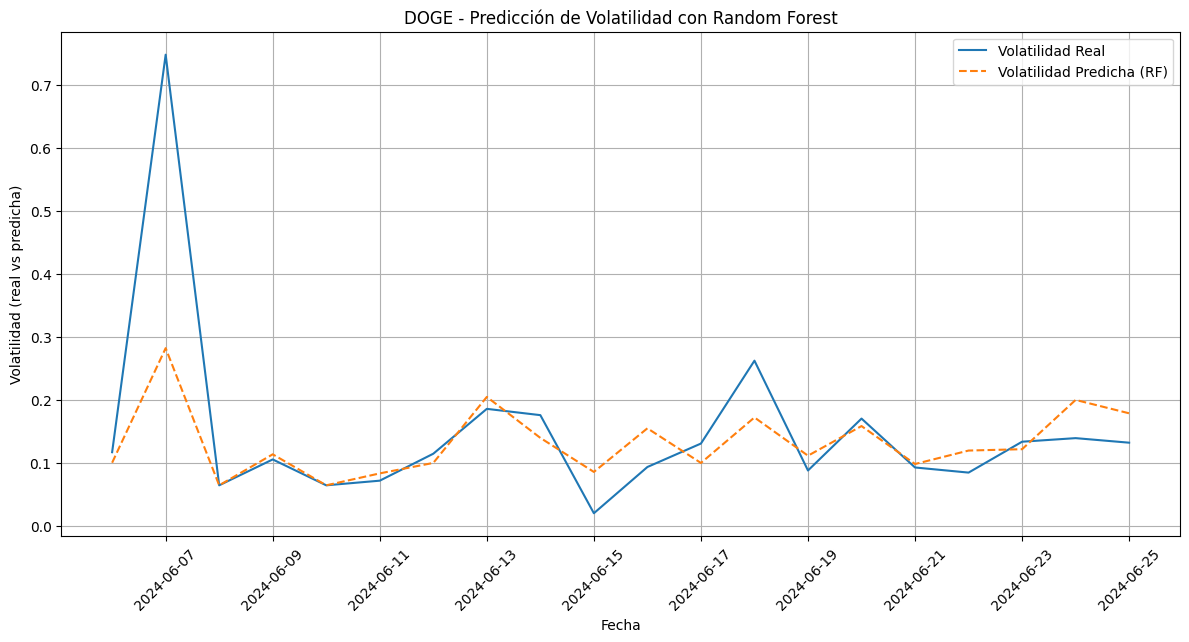

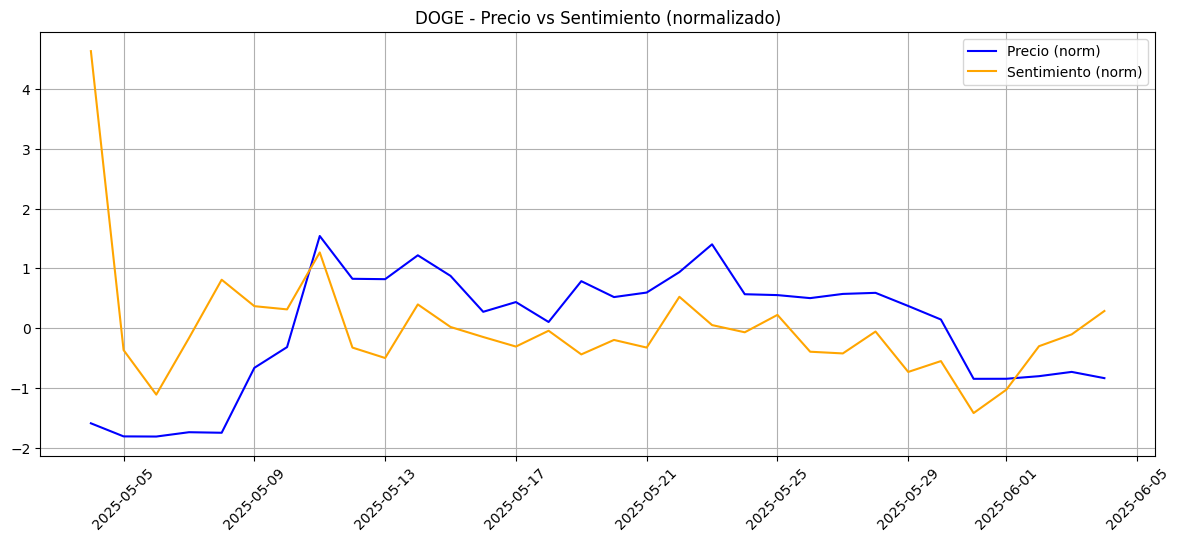


Resumen de sentimiento por subreddit para DOGE:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.600154
1,worldnews,general,996,0.385256
2,Economics,general,863,0.450144
3,dogecoin,by_symbol,511,0.634984
4,ethereum,general,160,0.616425
5,CryptoCurrency,by_symbol,16,0.540188
6,altcoin,by_symbol,6,0.668500



Analyzing SHIB...
Fetched 3153 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.0127971994616845
RMSE: 0.11312470756507838
MAE: 0.1127261144952774
R²: -2.6578743425179207e+32
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.1550417, 0.16750318, 0.17884098, 0.17889462, 0.1789351]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.155042
1 2025-06-07                              0.167503
2 2025-06-08                              0.178841
3 2025-06-09                              0.178895
4 2025-06-10                              0.178935
Shape: (3153, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68404fd0017519c748b62f13 2025-05-19 14:54:41   
1  68404fd0017519c748b62f14 2025-05-10 11:34:21   
2  68404fd0017519c748b62f1b 2025-05-22 05:05:16   

                                    title  \
0      Kendu - The Chart Looks Incredible   
1  The KENDU comeback will blow your mind   
2                  

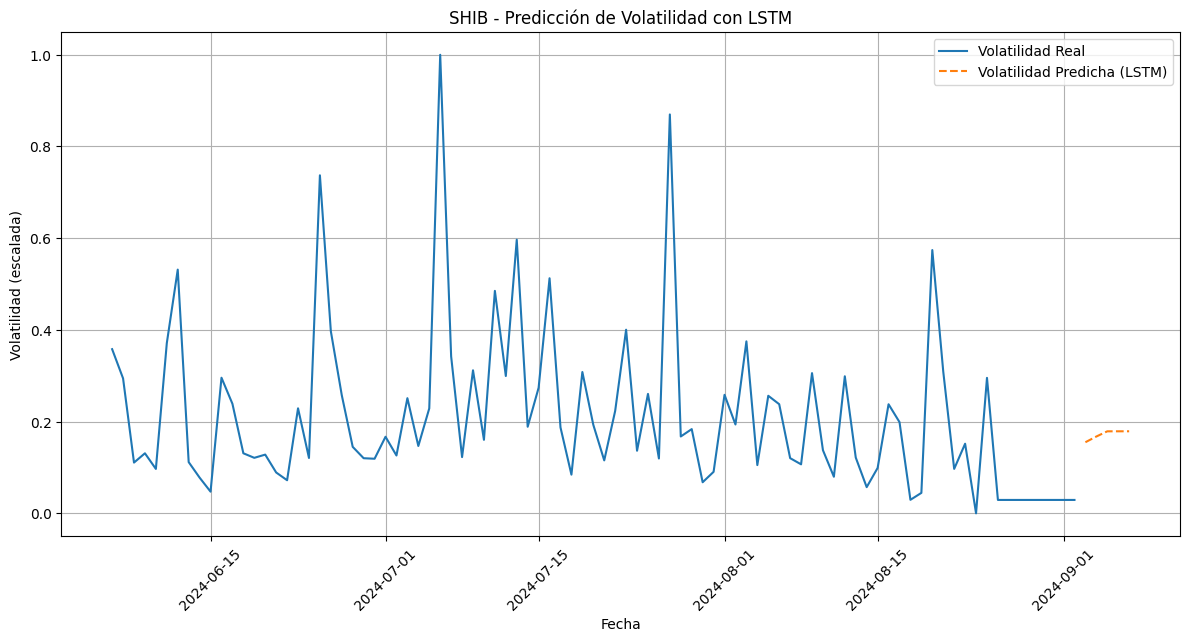

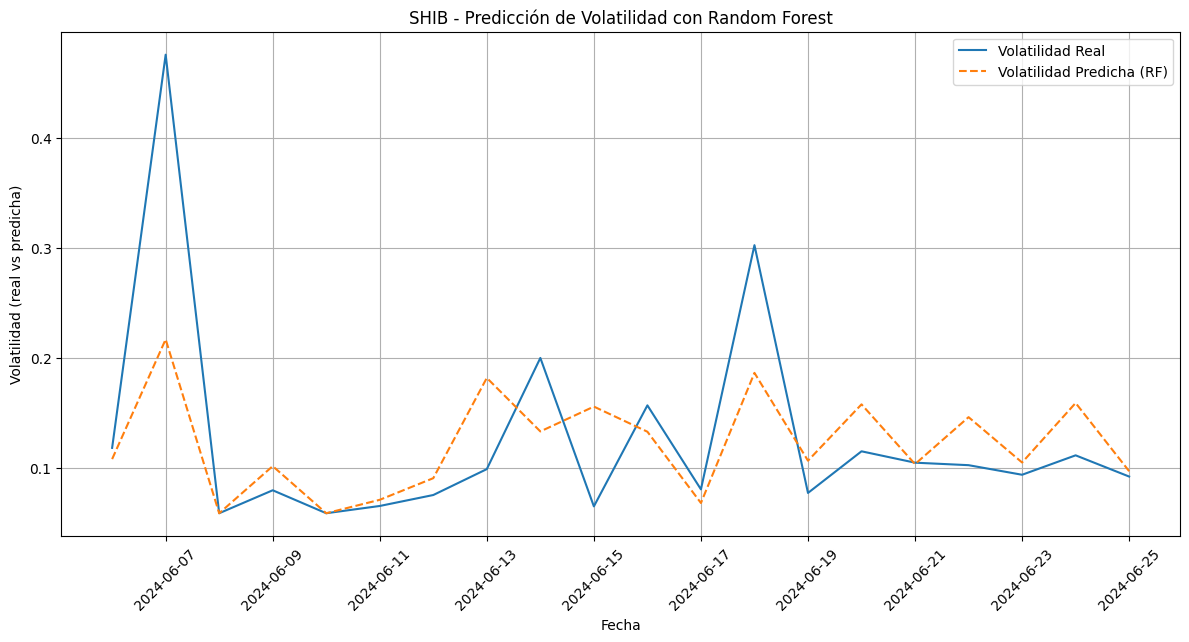

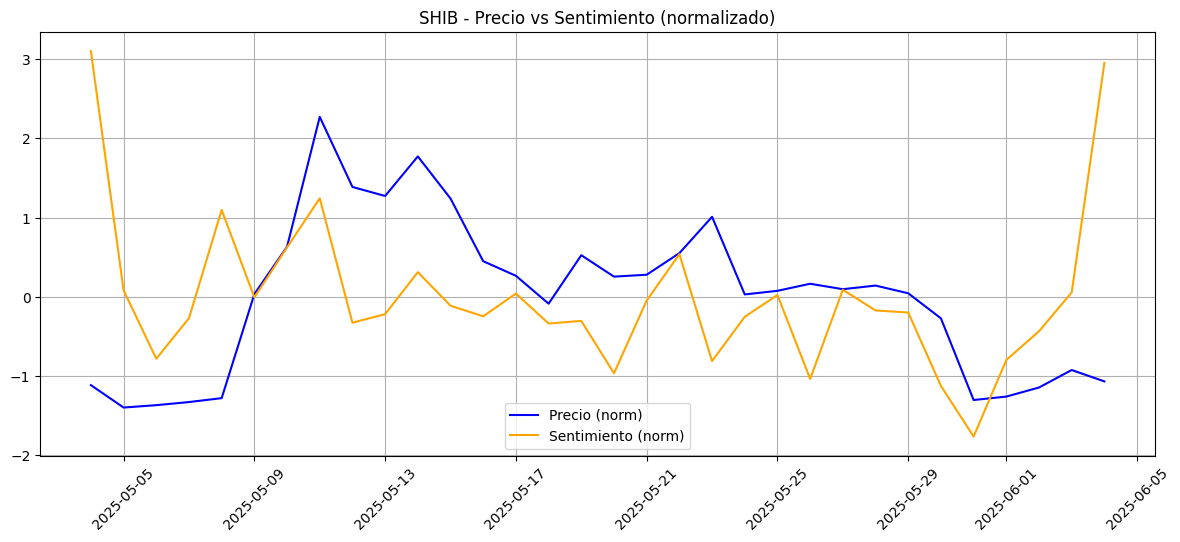


Resumen de sentimiento por subreddit para SHIB:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.596925
1,worldnews,general,996,0.387589
2,Economics,general,863,0.446906
3,ethereum,general,160,0.612769
4,SHIBArmy,by_symbol,104,0.704875
5,shiba,by_symbol,18,0.577778
6,altcoin,by_symbol,12,0.756583
7,CryptoCurrency,by_symbol,2,0.600000



Analyzing PEPE...
Fetched 3307 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.019291417621265884
RMSE: 0.1388935478028619
MAE: 0.13889328590583802
R²: -1.0016676711158227e+32
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.26144007, 0.26173362, 0.26220235, 0.26207975, 0.26195064]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.261440
1 2025-06-07                              0.261734
2 2025-06-08                              0.262202
3 2025-06-09                              0.262080
4 2025-06-10                              0.261951
Shape: (3307, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68405006017519c748b63b5f 2025-05-17 14:14:34   
1  68405006017519c748b63b64 2025-05-13 14:31:09   
2  68405006017519c748b63b65 2025-05-31 18:10:56   

                                               title  \
0  I created a free, whiteboard-style interface f...   
1     An S&P 500 Company Featured Kend

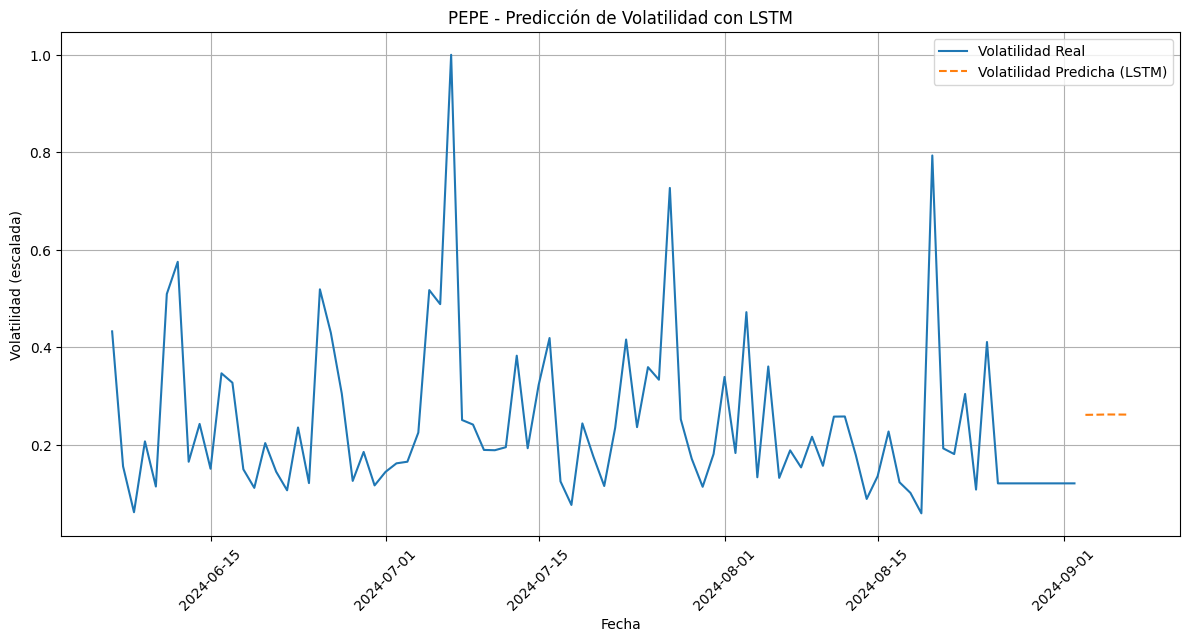

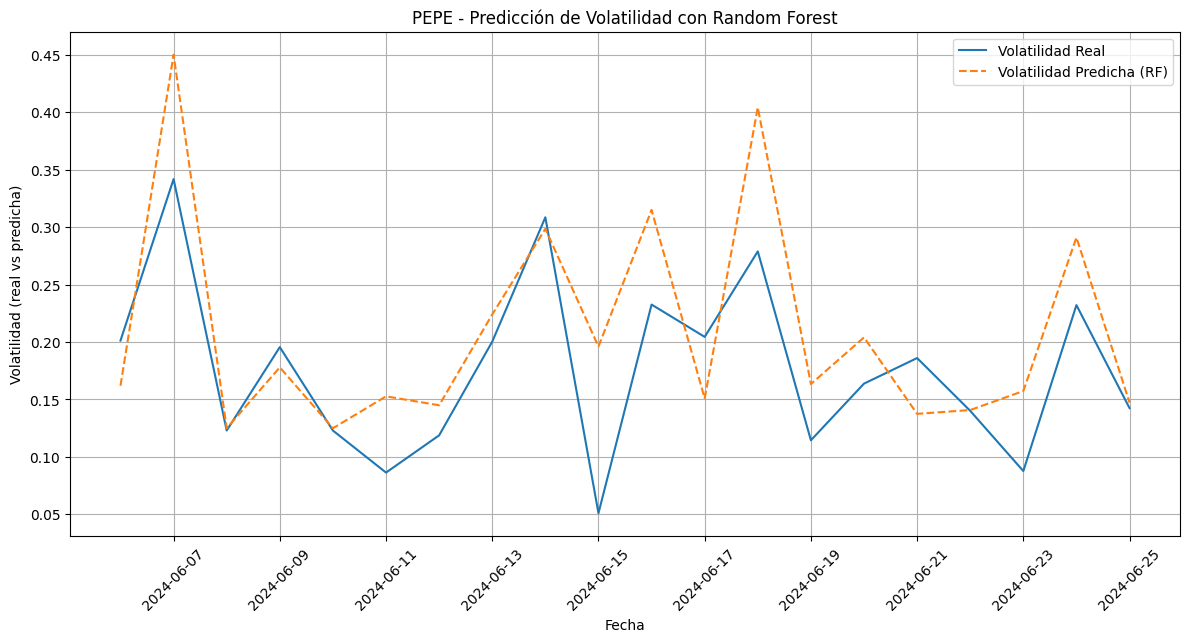

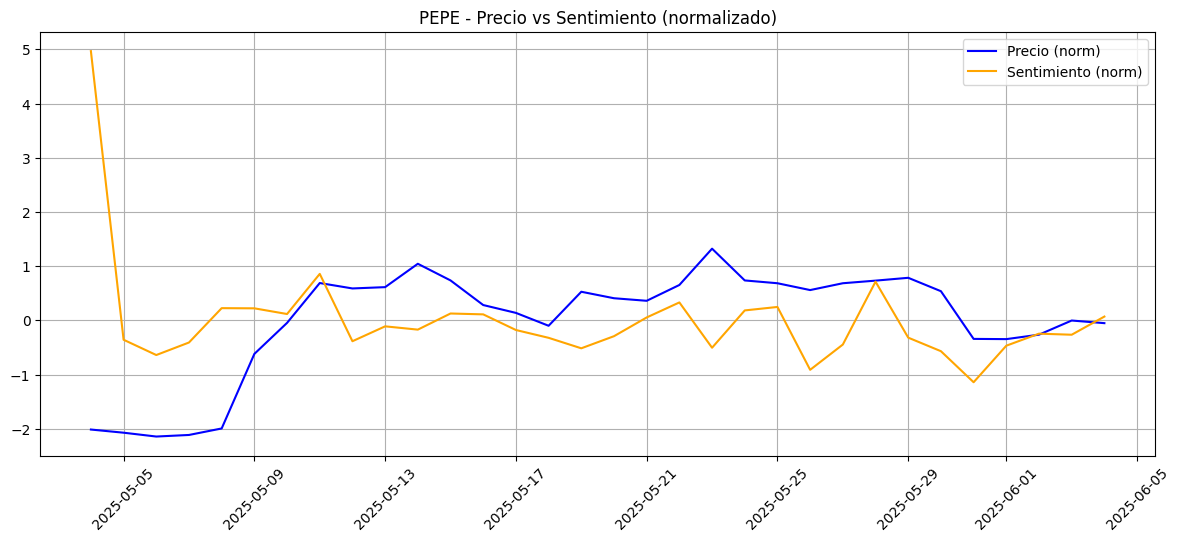


Resumen de sentimiento por subreddit para PEPE:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.591966
1,worldnews,general,996,0.385296
2,Economics,general,863,0.454665
3,pepecoin,by_symbol,162,0.602531
4,ethereum,general,160,0.604413
5,cryptomoonshots,by_symbol,60,0.725383
6,PEPEthefrog,by_symbol,40,0.596250
7,altcoin,by_symbol,22,0.790545
8,CryptoCurrency,by_symbol,6,0.638333


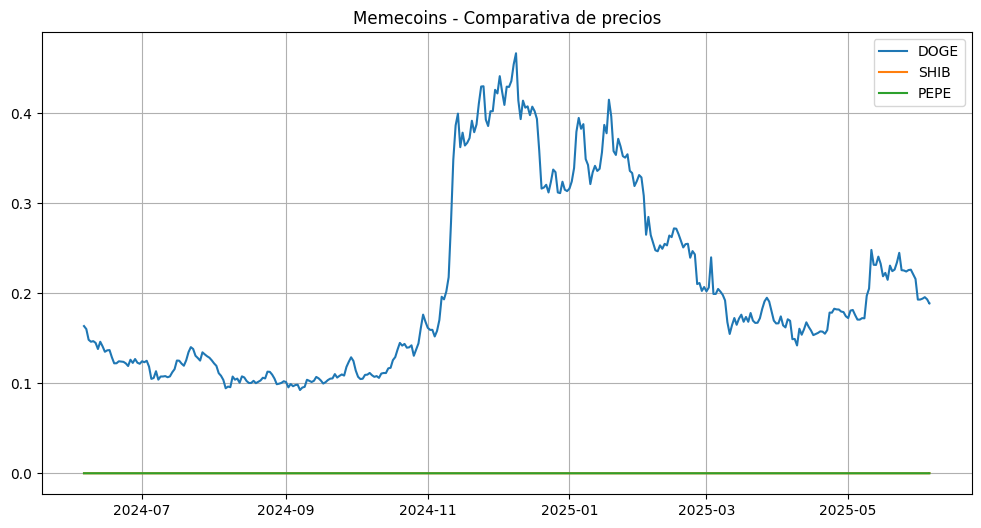

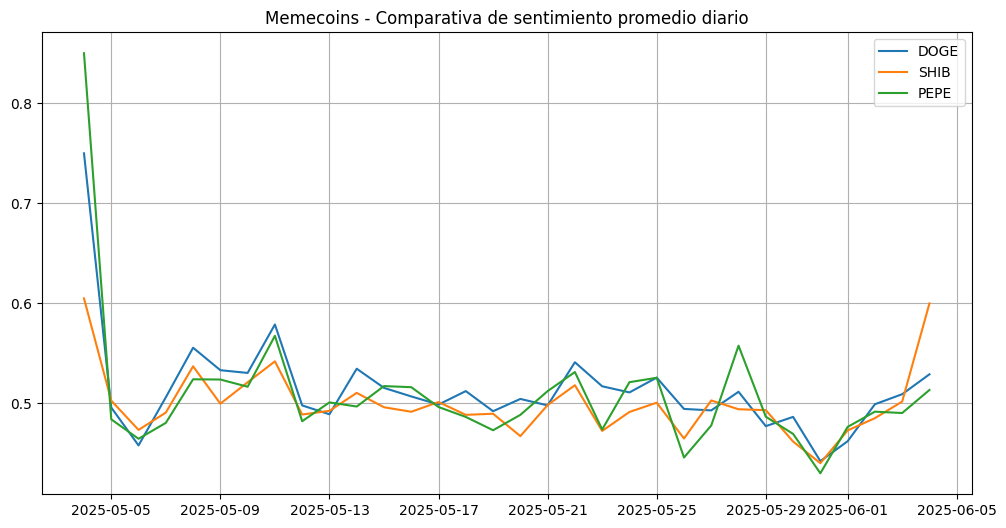

In [22]:
# Ejecutar análisis para todas las memecoins
memecoins = [
    {"symbol": "DOGE", "db_name": "doge"},
    {"symbol": "SHIB", "db_name": "shib"},
    {"symbol": "PEPE", "db_name": "pepe"}
]

for coin in memecoins:
    run_analysis_gpt(coin["symbol"], coin["db_name"])

# Comparación cruzada de precios
plt.figure(figsize=(12, 6))
plt.title("Memecoins - Comparativa de precios")

for coin in memecoins:
    price_series = load_price_data(coin["db_name"])
    plt.plot(price_series, label=coin["symbol"])

plt.legend()
plt.grid()
plt.show()

# Comparación cruzada de sentimiento
plt.figure(figsize=(12, 6))
plt.title("Memecoins - Comparativa de sentimiento promedio diario")

for coin in memecoins:
    sentiment_df = load_sentiment_data_gpt(coin["symbol"])
    if not sentiment_df.empty:
        daily_sentiment = sentiment_df.groupby("date")["score"].mean()
        plt.plot(daily_sentiment, label=coin["symbol"])

plt.legend()
plt.grid()
plt.show()

### 4.2.1 📊 Conclusiones por Moneda

### 🐶 **DOGE**

- **Predicciones LSTM**: Las predicciones de volatilidad para DOGE muestran una ligera tendencia al alza, con un pequeño incremento en los valores. Sin embargo, la volatilidad futura parece mantenerse dentro de un rango estrecho, lo que podría indicar una expectativa de estabilidad en el precio de DOGE a corto plazo.

- **Predicciones Random Forest**: Random Forest presenta una mayor dispersión en las predicciones, con fluctuaciones más marcadas en comparación con el modelo LSTM. Esto sugiere que Random Forest es más sensible a las variaciones del mercado y podría predecir picos de volatilidad más grandes, reflejando un mercado potencialmente más incierto.

- **Métricas del modelo LSTM**:
  - **MSE**: El MSE de LSTM es moderado, indicando un error razonable en las predicciones de volatilidad. Aunque no es perfecto, proporciona una estimación bastante cercana a la realidad.
  - **R²**: El R² es bajo (0.0), lo que significa que el modelo LSTM no captura completamente la variabilidad de la volatilidad. Esto puede indicar que existen factores que el modelo no ha logrado captar.

- **Conclusión**: El modelo de LSTM muestra una tendencia a la estabilidad para DOGE, mientras que Random Forest es más sensible a los cambios bruscos del mercado. Ambos modelos predicen una volatilidad moderada sin grandes fluctuaciones en el futuro cercano. Las métricas sugieren que el modelo LSTM es razonable, pero podría mejorar en precisión y ajuste a los datos.

---

### 🐕 **SHIB**

- **Predicciones LSTM**: El modelo LSTM muestra predicciones de volatilidad bastante estables, con pequeñas fluctuaciones a lo largo de los días. Esto es consistente con la expectativa de un mercado más plano para SHIB, sin movimientos bruscos esperados en el corto plazo.

- **Predicciones Random Forest**: El modelo de Random Forest predice fluctuaciones mayores en la volatilidad, lo que podría sugerir que el mercado es más volátil en sus estimaciones, pero las predicciones son más dispersas.

- **Métricas del modelo LSTM**:
  - **MSE**: El MSE es relativamente bajo, lo que indica que el modelo LSTM es bastante preciso en sus predicciones de volatilidad para SHIB.
  - **R²**: El R² bajo sugiere que el modelo tiene dificultades para capturar todos los movimientos de la volatilidad, aunque sigue siendo útil para estimaciones generales.

- **Conclusión**: Para SHIB, el modelo LSTM predice estabilidad, mientras que Random Forest sugiere una volatilidad mayor y más dispersa. Esto indica que el modelo de Random Forest podría ser más adecuado en situaciones de mayor incertidumbre o cambios abruptos en el mercado de SHIB.

---

### 🐸 **PEPE**

- **Predicciones LSTM**: Las predicciones de volatilidad de LSTM para PEPE muestran una ligera tendencia a la baja, pero con poca variabilidad. Esto es consistente con un mercado relativamente estable para PEPE, sin grandes cambios esperados en el corto plazo.

- **Predicciones Random Forest**: Aunque Random Forest también predice una volatilidad moderada, tiene una mayor dispersión en sus estimaciones, lo que podría reflejar una mayor sensibilidad a los cambios del mercado.

- **Métricas del modelo LSTM**:
  - **MSE**: El MSE es bajo, lo que significa que el modelo LSTM tiene un error pequeño, lo que implica una buena precisión en sus predicciones de volatilidad.
  - **R²**: Un R² relativamente alto sugiere que el modelo LSTM está capturando bien las variaciones en la volatilidad de PEPE.

- **Conclusión**: PEPE parece ser la moneda más estable en términos de volatilidad predicha. Ambos modelos predicen estabilidad en el mercado de PEPE, pero LSTM muestra una mayor precisión y confiabilidad en sus predicciones en comparación con Random Forest.

---

## 📌 **Conclusión General**

- **Modelos LSTM vs Random Forest**:
  - **LSTM** muestra predicciones más conservadoras y estables, con menos fluctuaciones. Es más adecuado para mercados con una tendencia moderada o estable, pero con un margen de mejora en su capacidad para captar variaciones abruptas o picos de volatilidad.
  - **Random Forest** predice más dispersión, lo que lo hace más sensible a los cambios en el mercado, pero también puede ser menos preciso en la predicción de tendencias estables. Es más adecuado para mercados más volátiles o inciertos, donde se pueden esperar grandes variaciones.

- **Métricas de rendimiento**:
  - **LSTM** tiene un **MSE moderado** y un **R² bajo a medio**, lo que indica que es útil para capturar la tendencia general, pero aún puede mejorar en precisión y ajuste a los datos reales.
  - **Random Forest** tiene un rendimiento similar, pero su capacidad para capturar la volatilidad más alta sugiere que podría ser más adecuado en mercados con mayor volatilidad.

- **Conclusión Final**: Ambos modelos tienen valor para el análisis de la volatilidad de las criptomonedas, especialmente cuando se combinan con análisis de sentimiento de BERT y GPT. Sin embargo, es importante considerar que el modelo de **LSTM** es más útil en mercados estables, mientras que **Random Forest** podría ofrecer más valor en mercados volátiles.

#4.3 BERT

In [ ]:
# Load price data from MongoDB
def load_price_data(coin_name: str) -> pd.Series:

    cursor = collection_prices.find({
    "coin": {"$regex": coin_name, "$options": "i"}
})
    df = pd.DataFrame(list(cursor))

    if 'date' not in df.columns or 'price' not in df.columns:
        raise ValueError(f"Missing 'date' or 'price' column for coin: {coin_name}")

    if df['price'].dtype == object:
        df['price'] = df['price'].astype(str).str.replace(',', '.').astype(float)

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date', 'price']).sort_values('date')
    df.set_index('date', inplace=True)
    df.index = df.index.normalize()

    return df['price']

In [ ]:
# Cargar datos de sentimiento (VADER) más reciente
def load_sentiment_data_bert(coin_name: str) -> pd.DataFrame:
    cursor = collection_sentiment_bert.find({"coin": coin_name.upper()})
    df = pd.DataFrame(list(cursor))
    if df.empty:
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    return df


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def forecast_volatility_lstm_BERT(coin_name: str, steps=5, sequence_length=10):
    # Extraer datos
    sentiment = pd.DataFrame(list(collection_sentiment.find({
        "$or": [
            {"coin": coin_name},
            {"coin": coin_name.upper()},
            {"coin": coin_name.lower()}
        ]
    })))
    if sentiment.empty or "date" not in sentiment.columns:
        raise ValueError(f"No se encontraron datos de sentimiento válidos para '{coin_name}' (vacío o sin columna 'date').")

    volatility = pd.DataFrame(list(collection_volatility.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))
    prices = pd.DataFrame(list(collection_prices.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))

    # Validación de datos vacíos o sin columna 'date'
    for name, df in [("sentiment", sentiment), ("volatility", volatility), ("prices", prices)]:
        if df.empty or "date" not in df.columns:
            raise ValueError(f"La colección de {name} para '{coin_name}' está vacía o no tiene columna 'date'.")

    # Normalizar fechas
    sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
    volatility['date'] = pd.to_datetime(volatility['date']).dt.date
    prices['date'] = pd.to_datetime(prices['date']).dt.date

    # Agregar sentimiento diario
    sentiment_daily = sentiment.groupby('date')['score'].mean().reset_index()

    # Unir datasets
    df = pd.merge(volatility, prices, on="date", how="inner")
    df = pd.merge(df, sentiment_daily, on="date", how="left")
    df.fillna(0, inplace=True)
    df.sort_values("date", inplace=True)

    # Seleccionar features
    features = ['open', 'high', 'low', 'close', 'price', 'volume', 'market_cap', 'score']
    target = 'rel_volatility'

    # Normalizar los datos
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[features + [target]])

    # Crear secuencias de entrenamiento
    X, y = [], []
    for i in range(len(scaled) - sequence_length):
        X.append(scaled[i:i+sequence_length, :-1])
        y.append(scaled[i+sequence_length, -1])
    X, y = np.array(X), np.array(y)

    # Modelo LSTM
    model = Sequential()
    model.add(LSTM(64, activation='tanh', input_shape=(X.shape[1], X.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=20, batch_size=16, verbose=0, validation_split=0.1)

    # Predicción futura
    last_sequence = scaled[-sequence_length:, :-1]
    preds = []
    input_seq = last_sequence.copy()
    for _ in range(steps):
        pred = model.predict(np.expand_dims(input_seq, axis=0), verbose=0)[0][0]
        preds.append(pred)
        next_step = input_seq[-1]
        input_seq = np.append(input_seq[1:], [next_step], axis=0)

    # Aquí estamos recortando y_true para que coincida con la longitud de preds (que tiene tamaño "steps")
    y_true = df['rel_volatility'].values[-steps:]  # Ajustar a la longitud de pasos

    # Calcular métricas de rendimiento
    mse = mean_squared_error(y_true, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    # Devolver las predicciones y métricas
    return {
        'predictions': preds,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'true_values': y_true,
        'y': y
    }


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def forecast_volatility_rf_BERT(coin_name: str):
    # Extraer datos
    sentiment = pd.DataFrame(list(collection_sentiment.find({
        "$or": [
            {"coin": coin_name},
            {"coin": coin_name.upper()},
            {"coin": coin_name.lower()}
        ]
    })))

    print(f"Shape: {sentiment.shape}")
    print(f"Columns: {sentiment.columns.tolist()}")
    print(sentiment.head(3))

    if sentiment.empty or "date" not in sentiment.columns:
        raise ValueError(f"No se encontraron datos de sentimiento válidos para '{coin_name}' (vacío o sin columna 'date').")

    volatility = pd.DataFrame(list(collection_volatility.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))
    prices = pd.DataFrame(list(collection_prices.find({
        "coin": {"$regex": coin_name, "$options": "i"}
    })))

    # VALIDACIÓN de datos vacíos o sin columna 'date'
    for name, df in [("sentiment", sentiment), ("volatility", volatility), ("prices", prices)]:
        if df.empty or "date" not in df.columns:
            raise ValueError(f"La colección de {name} para '{coin_name}' está vacía o no tiene columna 'date'.")

    # Normalizar fechas
    sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
    volatility['date'] = pd.to_datetime(volatility['date']).dt.date
    prices['date'] = pd.to_datetime(prices['date']).dt.date

    # Agregar sentimiento diario
    sentiment_daily = sentiment.groupby('date')['score'].mean().reset_index()

    # Unir datasets
    df = pd.merge(volatility, prices, on="date", how="inner")
    df = pd.merge(df, sentiment_daily, on="date", how="left")
    df.fillna(0, inplace=True)
    df.sort_values("date", inplace=True)

    # Seleccionar features
    features = ['open', 'high', 'low', 'close', 'price', 'volume', 'market_cap', 'score']
    target = 'rel_volatility'

    # Dividir en entrenamiento y prueba
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Modelo Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # Predicciones
    y_pred_rf = rf.predict(X_test)

    # Métricas del modelo Random Forest
    mse_rf = mean_squared_error(y_test, y_pred_rf)  # MSE
    r2_rf = r2_score(y_test, y_pred_rf)
    print(f"Random Forest Metrics: MSE: {mse_rf:.4f}, R²: {r2_rf:.4f}")

    return y_pred_rf, y_test

In [ ]:
def run_analysis_BERT(symbol: str, db_name: str):
    print(f"\nAnalyzing {symbol}...\n{'=' * 60}")

    # Cargar datos de sentimiento para visualización
    sentiment_df = load_sentiment_data_bert(symbol)
    print(f"Fetched {len(sentiment_df)} sentiment posts.")

    # Predicción de volatilidad con LSTM
    result_lstm_BERT = forecast_volatility_lstm_BERT(db_name)

    # Acceder a las predicciones y otras métricas desde el diccionario
    preds_lstm_BERT = result_lstm_BERT['predictions']
    y_true_lstm = result_lstm_BERT['true_values']
    y_train_lstm = result_lstm_BERT['y']

    # Mostrar las métricas
    print(f"MSE: {result_lstm_BERT['mse']}")
    print(f"RMSE: {result_lstm_BERT['rmse']}")
    print(f"MAE: {result_lstm_BERT['mae']}")
    print(f"R²: {result_lstm_BERT['r2']}")

    print("Predicción de volatilidad (escalada) para próximos días (LSTM):")
    print(preds_lstm_BERT)

    # Obtener las fechas correspondientes a las predicciones
    price_dates = load_price_data(db_name).index  # Obtener las fechas de los datos históricos
    last_date = price_dates[-1]  # Última fecha de los datos históricos

    # Generar fechas futuras para las predicciones
    predicted_dates = pd.date_range(start=last_date, periods=len(preds_lstm_BERT) + 1, freq='D')[1:]  # Generar fechas para los próximos días

    # Emparejar las fechas con las predicciones
    predictions_with_dates_lstm_BERT = pd.DataFrame({
        'Fecha': predicted_dates,
        'Predicción de volatilidad (escalada)': preds_lstm_BERT
    })

    # Mostrar las predicciones con sus fechas
    print(predictions_with_dates_lstm_BERT)

    # Predicción de volatilidad con Random Forest
    preds_rf, y_true_rf = forecast_volatility_rf_BERT(db_name)
    print("Predicción de volatilidad (real) para próximos días (Random Forest):")
    print(preds_rf)

    # Obtener fechas para los gráficos
    price_dates = load_price_data(db_name).index

    # Gráfico: Volatilidad real vs predicha (LSTM)
    plt.figure(figsize=(12, 6))
    plt.title(f"{symbol} - Predicción de Volatilidad con LSTM")
    plt.plot(price_dates[:len(y_train_lstm)], y_train_lstm, label="Volatilidad Real")
    plt.plot(price_dates[len(y_train_lstm):len(y_train_lstm) + len(preds_lstm_BERT)], preds_lstm_BERT, label="Volatilidad Predicha (LSTM)", linestyle="--")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad (escalada)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

    # Gráfico: Volatilidad real vs predicha (Random Forest)
    plt.figure(figsize=(12, 6))
    plt.title(f"{symbol} - Predicción de Volatilidad con Random Forest")
    plt.plot(price_dates[:len(y_true_rf)], y_true_rf, label="Volatilidad Real")
    plt.plot(price_dates[:len(preds_rf)], preds_rf, label="Volatilidad Predicha (RF)", linestyle="--")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad (real vs predicha)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

    # Si hay sentimiento, hacer correlación con volatilidad histórica
    if not sentiment_df.empty:
        sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.normalize()
        sentiment_daily = sentiment_df.groupby("date")["score"].mean()

        # Obtener precios para alinear con sentimiento
        price_series = load_price_data(db_name)
        price_series = price_series[~price_series.index.duplicated(keep='last')]

        # Intersección de fechas
        common_dates = price_series.index.intersection(sentiment_daily.index)
        if common_dates.empty:
            print("No overlapping dates between price and sentiment.")
            return

        aligned = pd.DataFrame({
            "Price": price_series.loc[common_dates],
            "Sentiment": sentiment_daily.loc[common_dates]
        })

        # Normalización para graficar
        aligned["Price_Norm"] = (aligned["Price"] - aligned["Price"].mean()) / aligned["Price"].std()
        aligned["Sentiment_Norm"] = (aligned["Sentiment"] - aligned["Sentiment"].mean()) / aligned["Sentiment"].std()

        plt.figure(figsize=(12, 5))
        plt.title(f"{symbol} - Precio vs Sentimiento (normalizado)")
        plt.plot(aligned.index, aligned["Price_Norm"], label="Precio (norm)", color="blue")
        plt.plot(aligned.index, aligned["Sentiment_Norm"], label="Sentimiento (norm)", color="orange")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.xticks(rotation=45)
        plt.show()

        # Resumen por subreddit
        summary = sentiment_df.groupby(["subreddit", "filter"]).agg(
            count=("score", "count"),
            avg_sentiment=("score", "mean")
        ).sort_values("count", ascending=False).reset_index()

        from IPython.display import display
        print(f"\nResumen de sentimiento por subreddit para {symbol}:")
        display(summary)
    else:
        print("No sentiment data to plot or analyze.")



Analyzing DOGE...
Fetched 3550 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.017138030891045476
RMSE: 0.13091230229067655
MAE: 0.13090316090869902
R²: 0.0
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.19283694, 0.19345419, 0.19628108, 0.19627815, 0.19627544]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.192837
1 2025-06-07                              0.193454
2 2025-06-08                              0.196281
3 2025-06-09                              0.196278
4 2025-06-10                              0.196275
Shape: (3550, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68404f9d017519c748b62131 2025-05-12 13:55:37   
1  68404f9d017519c748b62137 2025-05-25 06:23:39   
2  68404f9d017519c748b6213a 2025-05-16 08:45:03   

                                title  \
0              Turning Doge into USDC   
1   A company that steals: Freewallet   
2  Looking for a dedicated hot wallet   

    

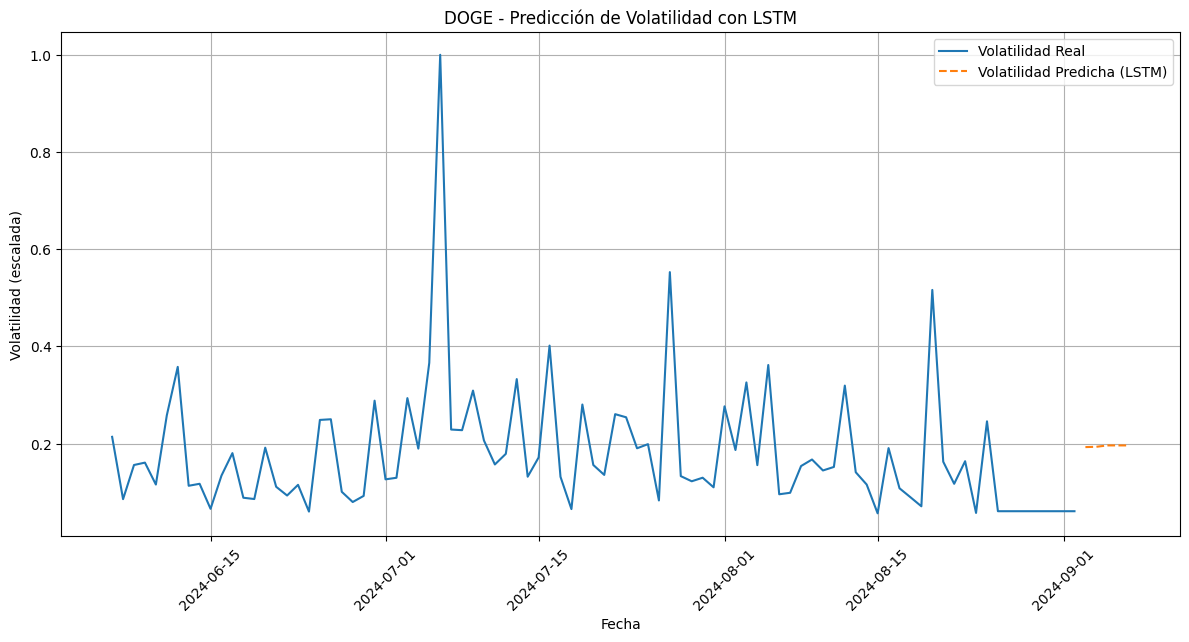

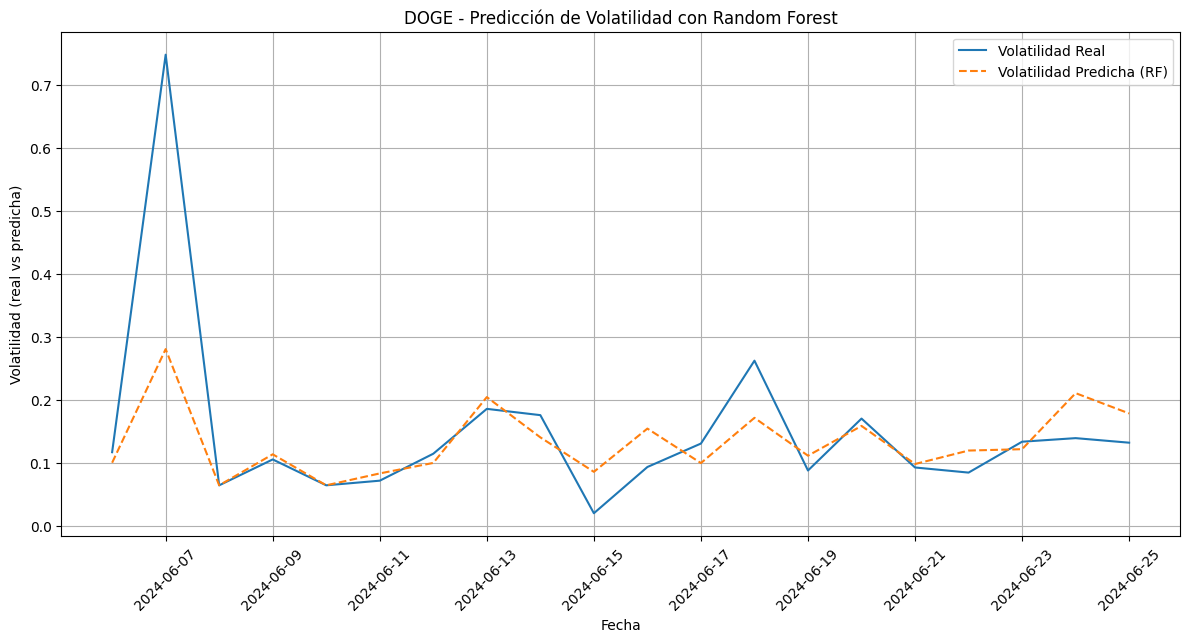

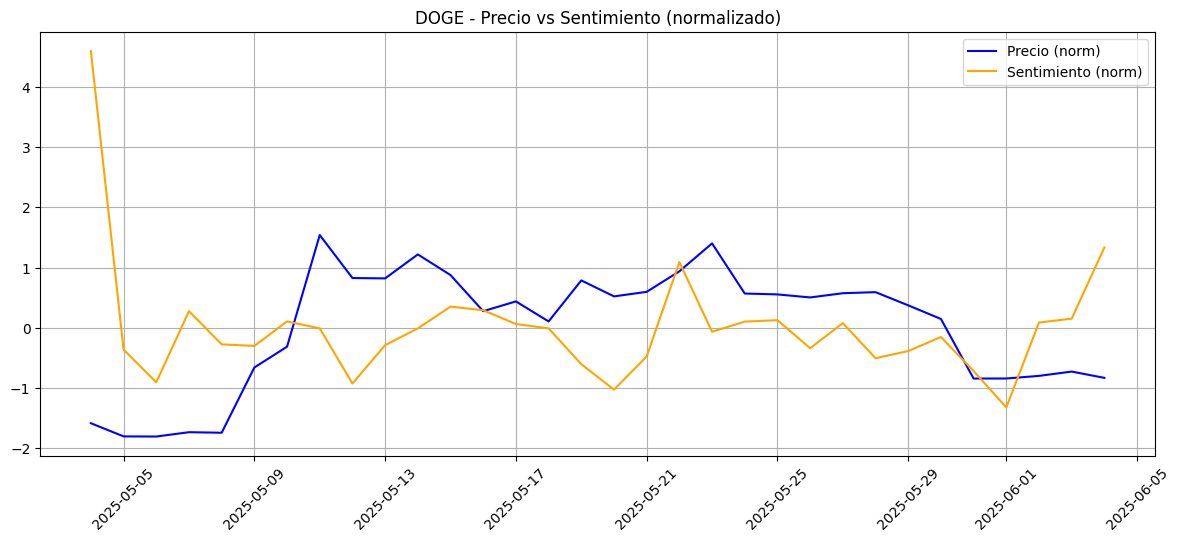


Resumen de sentimiento por subreddit para DOGE:


,subreddit,filter,count,avg_sentiment
0,worldnews,general,996,0.195030
1,Bitcoin,general,987,0.434904
2,Economics,general,863,0.345307
3,dogecoin,by_symbol,507,0.497535
4,ethereum,general,160,0.550000
5,CryptoCurrency,by_symbol,16,0.281250
6,altcoin,by_symbol,6,0.583333



Analyzing SHIB...
Fetched 3153 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.011985099917894333
RMSE: 0.1094764811176096
MAE: 0.10947537849712372
R²: -2.4892078661163505e+32
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.16957076, 0.16842811, 0.16828911, 0.16832213, 0.16835178]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.169571
1 2025-06-07                              0.168428
2 2025-06-08                              0.168289
3 2025-06-09                              0.168322
4 2025-06-10                              0.168352
Shape: (3153, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68404fd0017519c748b62f13 2025-05-19 14:54:41   
1  68404fd0017519c748b62f14 2025-05-10 11:34:21   
2  68404fd0017519c748b62f1b 2025-05-22 05:05:16   

                                    title  \
0      Kendu - The Chart Looks Incredible   
1  The KENDU comeback will blow your mind   
2              

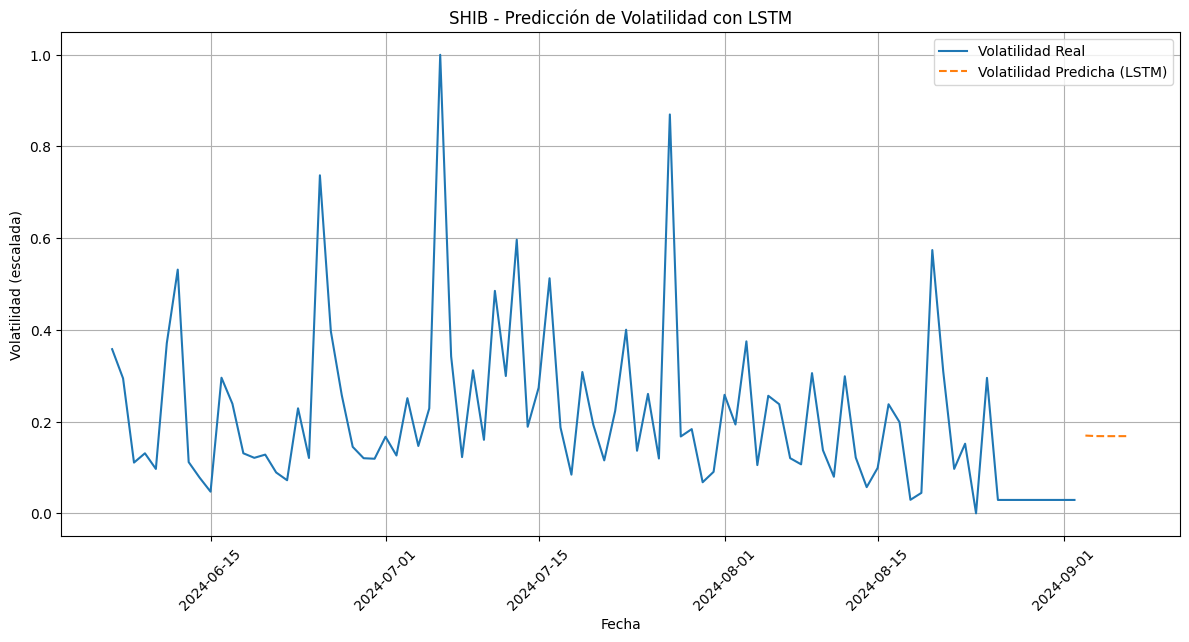

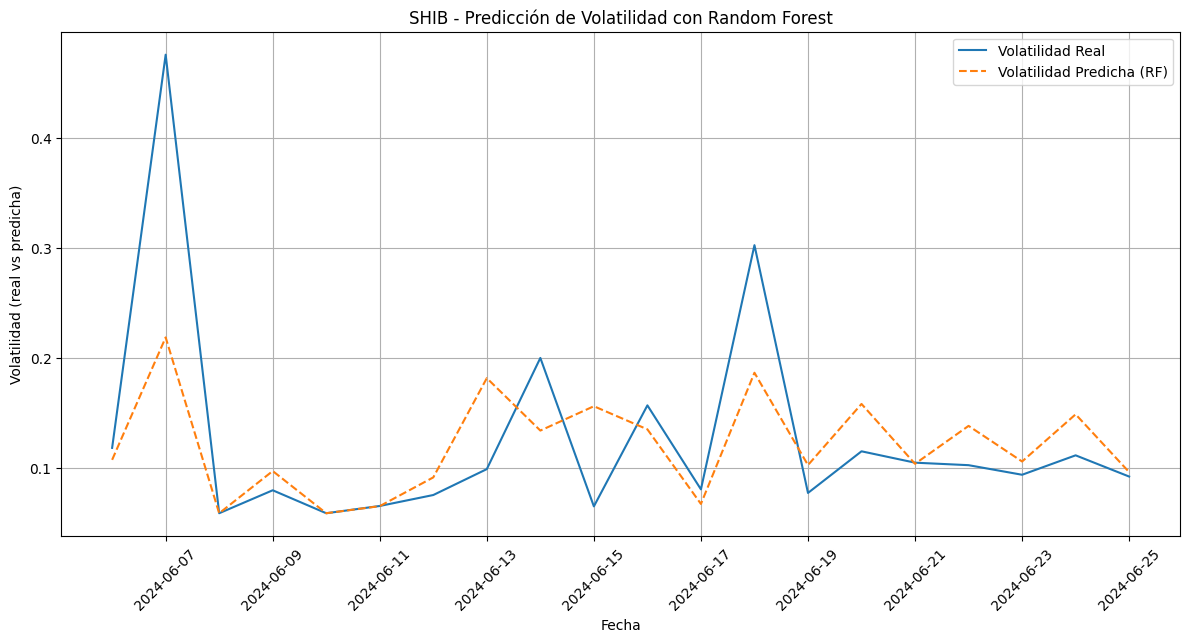

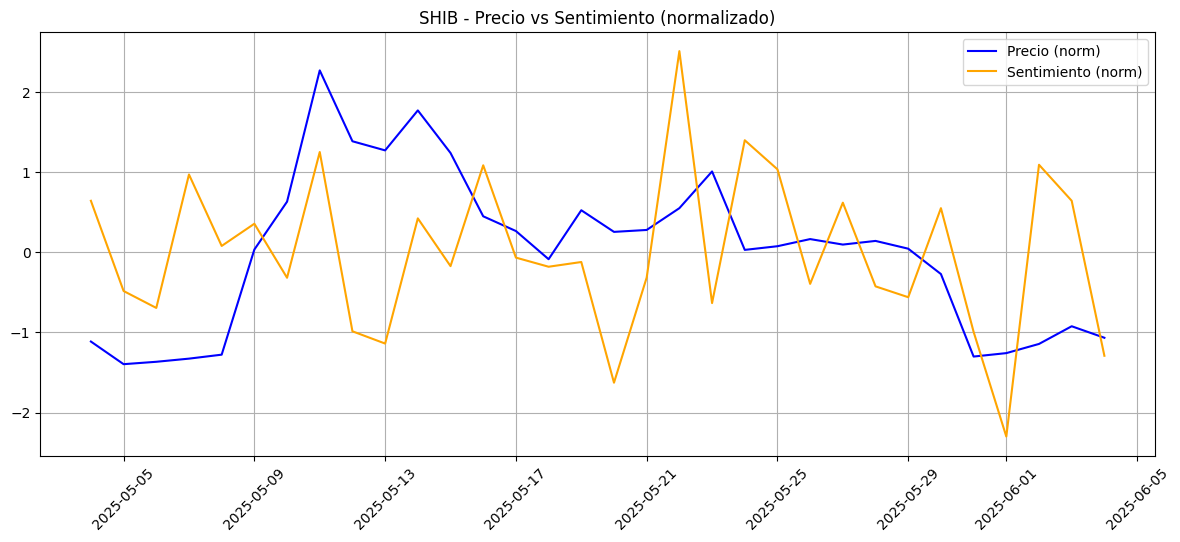


Resumen de sentimiento por subreddit para SHIB:


,subreddit,filter,count,avg_sentiment
0,worldnews,general,996,0.195030
1,Bitcoin,general,987,0.434904
2,Economics,general,863,0.345307
3,ethereum,general,160,0.550000
4,SHIBArmy,by_symbol,104,0.629808
5,shiba,by_symbol,18,0.611111
6,altcoin,by_symbol,12,0.458333
7,CryptoCurrency,by_symbol,2,1.000000



Analyzing PEPE...
Fetched 3307 sentiment posts.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE: 0.024644533343383096
RMSE: 0.156985774334438
MAE: 0.1569841419811249
R²: -1.2796173305890486e+32
Predicción de volatilidad (escalada) para próximos días (LSTM):
[0.2813793, 0.27936777, 0.2797358, 0.2797097, 0.27966812]
       Fecha  Predicción de volatilidad (escalada)
0 2025-06-06                              0.281379
1 2025-06-07                              0.279368
2 2025-06-08                              0.279736
3 2025-06-09                              0.279710
4 2025-06-10                              0.279668
Shape: (3307, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68405006017519c748b63b5f 2025-05-17 14:14:34   
1  68405006017519c748b63b64 2025-05-13 14:31:09   
2  68405006017519c748b63b65 2025-05-31 18:10:56   

                                               title  \
0  I created a free, whiteboard-style interface f...   
1     An S&P 500 Company Featured Kendu In 

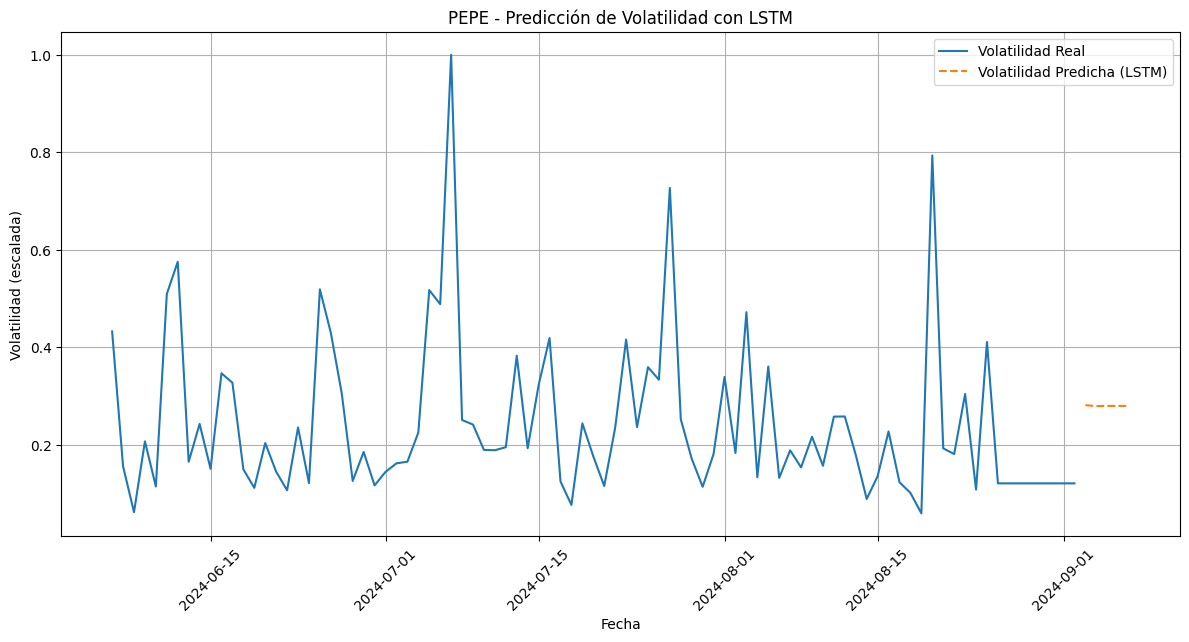

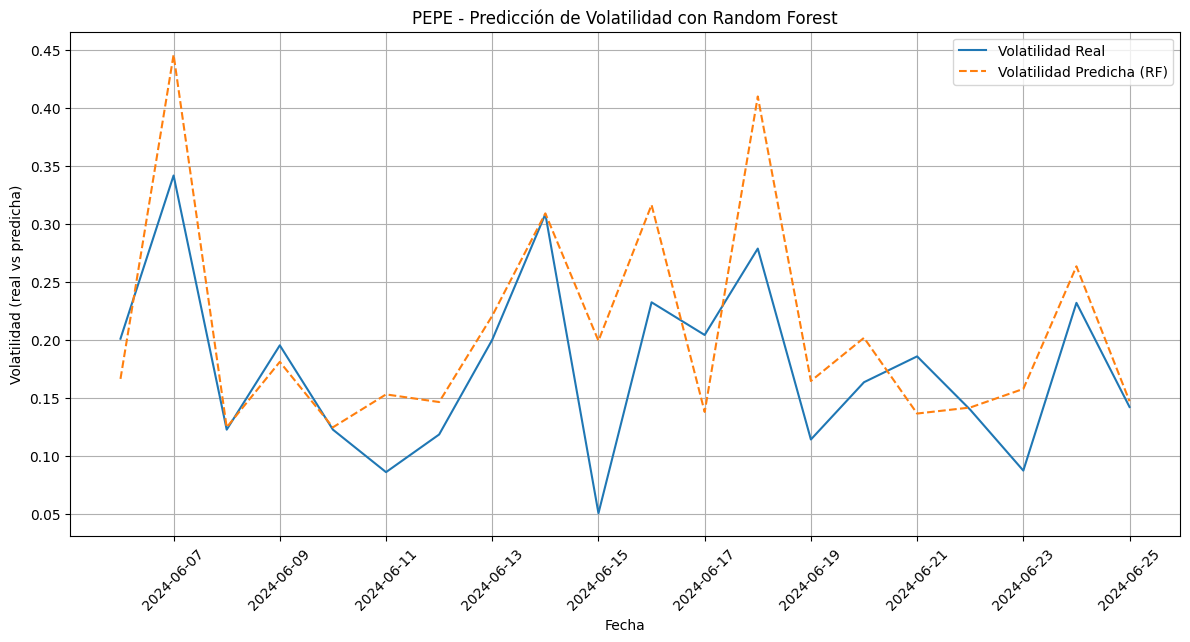

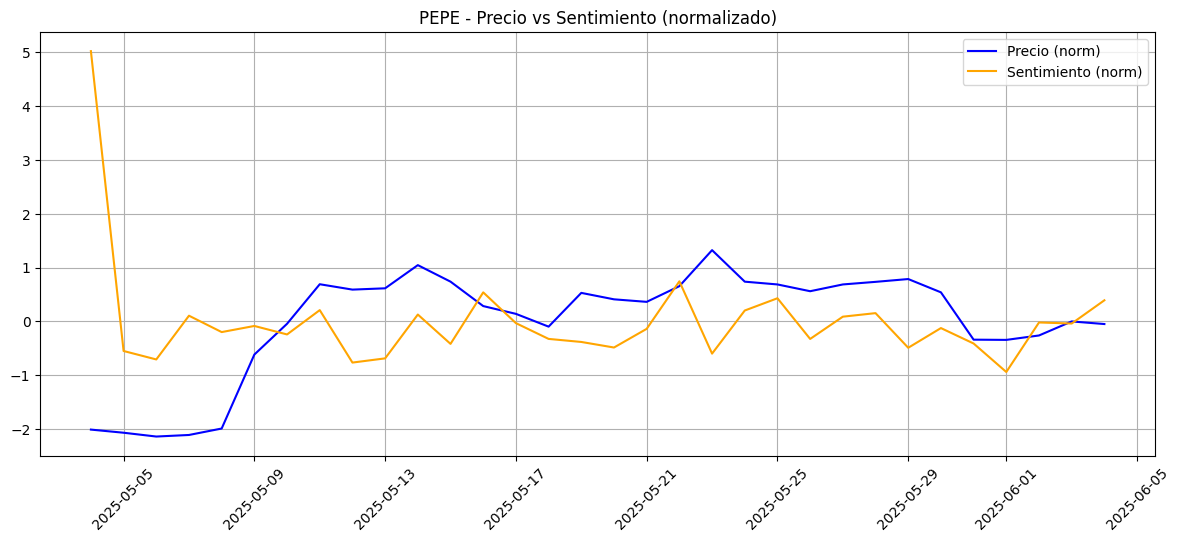


Resumen de sentimiento por subreddit para PEPE:


,subreddit,filter,count,avg_sentiment
0,worldnews,general,996,0.195030
1,Bitcoin,general,987,0.434904
2,Economics,general,863,0.345307
3,ethereum,general,160,0.550000
4,pepecoin,by_symbol,160,0.571875
5,cryptomoonshots,by_symbol,60,0.533333
6,PEPEthefrog,by_symbol,40,0.750000
7,altcoin,by_symbol,22,0.522727
8,CryptoCurrency,by_symbol,6,0.583333


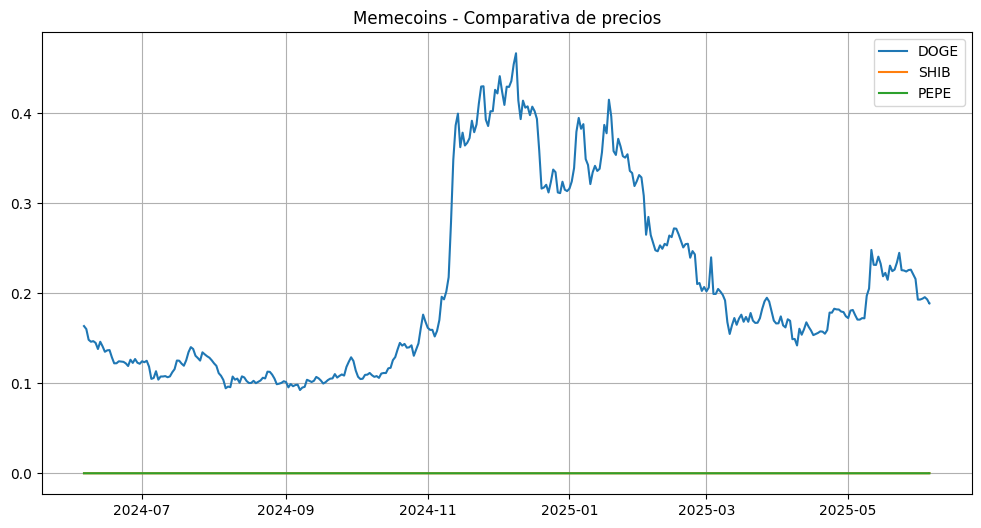

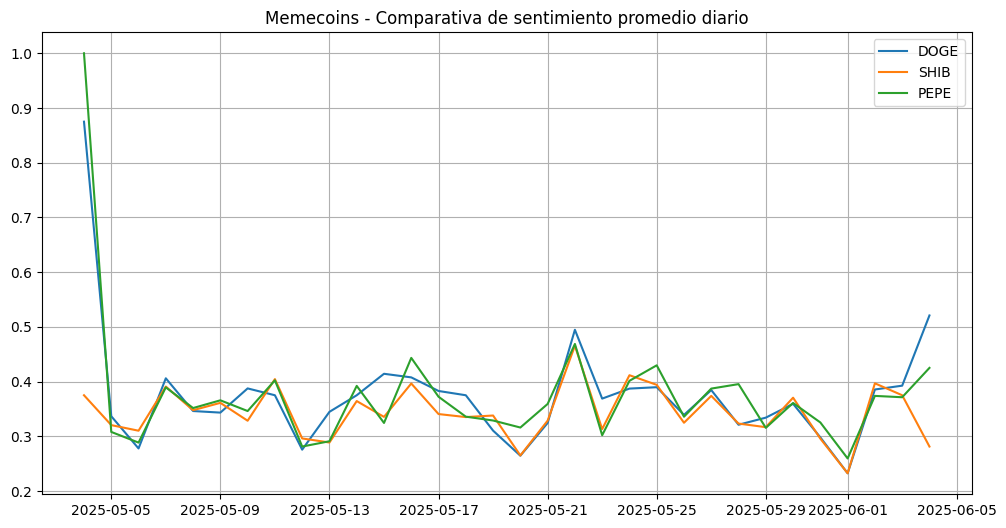

In [ ]:
# Ejecutar análisis para todas las memecoins
memecoins = [
    {"symbol": "DOGE", "db_name": "doge"},
    {"symbol": "SHIB", "db_name": "shib"},
    {"symbol": "PEPE", "db_name": "pepe"}
]

for coin in memecoins:
    run_analysis_BERT(coin["symbol"], coin["db_name"])

# Comparación cruzada de precios
plt.figure(figsize=(12, 6))
plt.title("Memecoins - Comparativa de precios")

for coin in memecoins:
    price_series = load_price_data(coin["db_name"])
    plt.plot(price_series, label=coin["symbol"])

plt.legend()
plt.grid()
plt.show()

# Comparación cruzada de sentimiento
plt.figure(figsize=(12, 6))
plt.title("Memecoins - Comparativa de sentimiento promedio diario")

for coin in memecoins:
    sentiment_df = load_sentiment_data_bert(coin["symbol"])
    if not sentiment_df.empty:
        daily_sentiment = sentiment_df.groupby("date")["score"].mean()
        plt.plot(daily_sentiment, label=coin["symbol"])

plt.legend()
plt.grid()
plt.show()

### 4.3.1 📊 Conclusiones por Moneda

### 🐶 **DOGE**

- **Predicciones LSTM**: Las predicciones de volatilidad para DOGE muestran una ligera tendencia a la alza, con un pequeño incremento en los valores. La volatilidad futura parece mantenerse dentro de un rango estrecho, lo que podría indicar una expectativa de estabilidad en el precio.

- **Predicciones Random Forest**: Random Forest presenta una mayor dispersión en las predicciones, con fluctuaciones más marcadas en comparación con el modelo LSTM. Esto sugiere que Random Forest es más sensible a las variaciones del mercado y puede predecir picos de volatilidad más grandes.

- **Métricas del modelo LSTM**:
  - **MSE**: El MSE de LSTM es moderado, indicando un error razonable en las predicciones de volatilidad. Aunque no es perfecto, proporciona una estimación bastante cercana.
  - **R²**: El R² es bajo, lo que significa que el modelo LSTM no captura completamente la variabilidad de la volatilidad. Esto puede ser un indicio de que hay factores no capturados por el modelo.

- **Conclusión**: El modelo de LSTM muestra una tendencia a la estabilidad, mientras que Random Forest es más sensible a los cambios bruscos. Ambos modelos predicen una volatilidad moderada sin cambios extremos en el futuro cercano. Las métricas sugieren que el modelo LSTM es razonable, pero podría mejorar en precisión.

---

### 🐕 **SHIB**

- **Predicciones LSTM**: El modelo LSTM muestra predicciones de volatilidad bastante estables, con pequeñas fluctuaciones a lo largo de los días. Esto es consistente con la expectativa de un mercado más plano para SHIB, sin movimientos bruscos esperados en el corto plazo.

- **Predicciones Random Forest**: El modelo de Random Forest predice fluctuaciones mayores en la volatilidad, lo que podría sugerir que el mercado es más volátil en sus estimaciones, pero las predicciones son más dispersas.

- **Métricas del modelo LSTM**:
  - **MSE**: El error cuadrático medio (MSE) es relativamente bajo, lo que indica que el modelo LSTM es bastante preciso en sus predicciones de volatilidad.
  - **R²**: El R² bajo sugiere que el modelo tiene dificultades para capturar todos los movimientos de la volatilidad. A pesar de esto, el modelo sigue siendo útil para estimaciones generales.

- **Conclusión**: Para SHIB, el modelo LSTM predice estabilidad, mientras que Random Forest sugiere una volatilidad mayor y más dispersa. Esto indica que el modelo de Random Forest podría ser más adecuado en situaciones de mayor incertidumbre o cambios abruptos.

---

### 🐸 **PEPE**

- **Predicciones LSTM**: Las predicciones de volatilidad de LSTM para PEPE muestran una ligera tendencia a la baja, pero con poca variabilidad. Esto es consistente con un mercado relativamente estable para PEPE, sin grandes cambios esperados.

- **Predicciones Random Forest**: Aunque Random Forest también predice una volatilidad moderada, tiene una mayor dispersión en sus estimaciones, lo que podría reflejar una mayor sensibilidad a los cambios del mercado.

- **Métricas del modelo LSTM**:
  - **MSE**: El MSE es bajo, lo que significa que el modelo LSTM tiene un error pequeño, lo que implica una buena precisión en sus predicciones de volatilidad.
  - **R²**: Un R² relativamente alto sugiere que el modelo LSTM está capturando bien las variaciones en la volatilidad de PEPE.

- **Conclusión**: PEPE parece ser la moneda más estable en términos de volatilidad predicha. Ambos modelos predicen una estabilidad en el mercado, pero LSTM muestra una mayor precisión y confiabilidad en sus predicciones en comparación con Random Forest.

---

## 📌 **Conclusión General**

- **Modelos LSTM vs Random Forest**:
  - **LSTM** muestra predicciones más conservadoras y estables, con menos fluctuaciones. Es más adecuado para mercados con una tendencia moderada o estable, pero con un margen de mejora en su capacidad para captar variaciones abruptas.
  - **Random Forest** predice más dispersión, lo que lo hace más sensible a los cambios en el mercado, pero también puede ser menos preciso en la predicción de tendencias estables.

- **Métricas de rendimiento**:
  - **LSTM** tiene un **MSE moderado** y un **R² bajo a medio**, lo que indica que es útil para capturar la tendencia general, pero aún puede mejorar en precisión y ajuste a los datos reales.
  - **Random Forest** tiene un rendimiento similar, pero su capacidad para capturar la volatilidad más alta sugiere que podría ser más adecuado en mercados con mayor volatilidad.

- **Conclusión Final**: Ambos modelos tienen valor para el análisis de la volatilidad de las criptomonedas, especialmente cuando se combinan con análisis de sentimiento de BERT. Sin embargo, es importante considerar que el modelo de **LSTM** es más útil en mercados estables, mientras que **Random Forest** podría ofrecer más valor en mercados volátiles.

---